<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [60]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [61]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# **Loading the dataset**

In [62]:
#from google.colab import drive
#drive.mount('/content/drive')
from google.colab import files
f = files.upload()

Saving EasyVisa.csv to EasyVisa (1).csv


In [63]:

# Reading datasets by using read_csv from pandas package - visa_data(vd)
#vd = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_Course/Project3- EasyVisa/EasyVisa.csv")
vd = pd.read_csv("EasyVisa.csv")


In [64]:
orig_data = vd.copy()

# **Overview of the Dataset**

In [65]:
vd.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Observations:
- case_status is the target variable
- case_id is not useful info and can be dropped
- education_of_employee can be hot encoded  to numbers
- yr_of_estab can be coverted to Age instead


In [66]:
vd.shape

(25480, 12)

In [67]:
vd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [68]:
# checking duplicate values
vd.duplicated().sum()

np.int64(0)

In [69]:
# checking missing/null values
vd.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


Observations:
-

- overall 25480 rows and 12 columns
- Case_id: not important and can be dropped
- Missing Values: 0 nulls found; data is completely filled.
- Duplicates: 0 duplicate rows; every entry is unique.
- only 3 are numeric and rest all are objects



# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [70]:
vd.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


Observations:
-

* Observations
  - no_of_employees: Contains negative errors (-26) and extreme right-skewness peaking at 602,069.
  - yr_of_estab: Focuses heavily on newer companies, with over 75% established after 1976.
  - prevailing_wage: Extreme variance (2.14 to 319,210.27) implies mixed time units (hourly/yearly) requiring scaling.

* Sanity checks
  - Negative Values: Error detected in no_of_employees (minimum is -26); needs to be converted or cleaned.
  - Wage Anomalies: Minimum wage is 2.14 while maximum is 319,210.27; requires standardizing since multiple time units (hourly/yearly) are mixed together.

In [71]:
#check how many Negative values in no_of_employees
vd.loc[vd["no_of_employees"] < 0].shape

(33, 12)

In [72]:
#Fix Negative values in no_of_employees, possibly a typo replace with abs value
vd['no_of_employees'] = abs(vd['no_of_employees'])

In [73]:
#Drop case_id
vd.drop('case_id', axis=1, inplace=True)

In [74]:
vd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


In [75]:
# understand all the categorical variables
all_cat_cols = [col for col in vd.columns if vd[col].dtype == 'object']
all_cat_cols
#remove case_status from all_cat_cols and save into cat_cols
cat_cols = [col for col in all_cat_cols if col != 'case_status']
cat_cols


['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position']

In [76]:
#check each of the all_cat_cols distribution between unique values &  percentages
for col in all_cat_cols:
    print(col)
    print(vd[col].value_counts(normalize=True)*100)
    print()

continent
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64

education_of_employee
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64

has_job_experience
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64

requires_job_training
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64

region_of_employment
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64

unit_of_wage
unit_of_wage
Year     90.117739
Hour      8.465463
Week      1.067504
Month     0.349294
Name: proportion, dtype: float64

full_time_position
full_time_position
Y    89.375981
N    10.624019
N

# Univariate Analysis

In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# Function to do Count Plot for all CATEGORICAL variables
# ─────────────────────────────────────────────────────────────────────────────

def plot_categorical(
    data: pd.DataFrame,
    column: str,
    hue: str | None = None,
    palette: str = "Set2",
    order: list | None = None,
    top_n: int | None = None,
    rotate_xticks: int = 0,
    figsize: tuple = (8, 4),
):
    """
    Count Plot for a categorical column.

    Parameters
    ----------
    data         : DataFrame
    column       : Categorical column to plot
    hue          : Optional target column to split bars by
    palette      : Seaborn palette
    order        : Explicit category order (overrides top_n)
    top_n        : Show only the top-N most frequent categories
    rotate_xticks: Rotate x-axis labels by this many degrees
    figsize      : (width, height)
    """
    plot_data = data[[column] + ([hue] if hue else [])].dropna()
    total     = len(plot_data)

    # ── Resolve bar order ──────────────────────────────────────────────────
    value_counts = plot_data[column].value_counts()
    if order is not None:
        plot_order = order
    elif top_n is not None:
        plot_order = value_counts.head(top_n).index.tolist()
    else:
        plot_order = value_counts.index.tolist()

    # ── Count Plot ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    sns.countplot(
        data=plot_data[plot_data[column].isin(plot_order)],
        x=column, order=plot_order,
        hue=hue, palette=palette, ax=ax,
    )
    ax.set_title(
        f"Count Plot of '{column}'" + (f"  |  by '{hue}'" if hue else ""),
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=rotate_xticks)

    # ── Bar labels: count + % (per bar when no hue; count only with hue) ──
    for p in ax.patches:
        h = int(p.get_height())
        if h == 0:
            continue
        label = f"{h}\n({h/total*100:.1f}%)" if not hue else f"{h}"
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center", va="bottom", fontsize=9, linespacing=1.4,
        )

    plt.tight_layout()
    plt.show()

    # ── Frequency table ────────────────────────────────────────────────────
    print(f"\n── '{column}' value counts ──")
    if hue:
        print(plot_data.groupby([column, hue]).size().unstack(fill_value=0).to_string())
    else:
        freq = (
            value_counts[plot_order]
            .reset_index(name="Count")
            .rename(columns={"index": column})
            .assign(Pct=lambda df: (df["Count"] / total * 100).round(1))
        )
        print(freq.to_string(index=False))


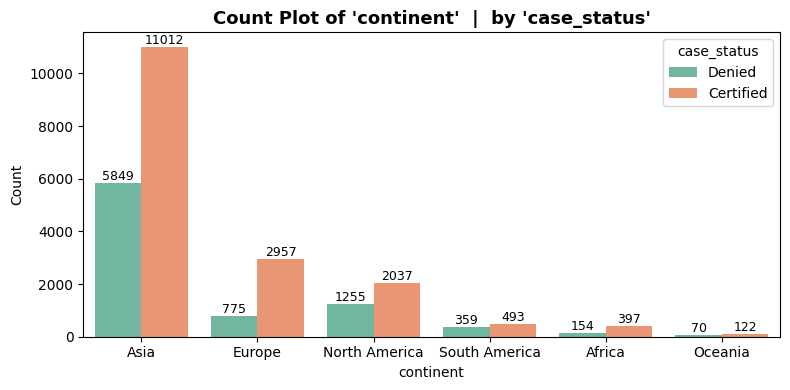


── 'continent' value counts ──
case_status    Certified  Denied
continent                       
Africa               397     154
Asia               11012    5849
Europe              2957     775
North America       2037    1255
Oceania              122      70
South America        493     359



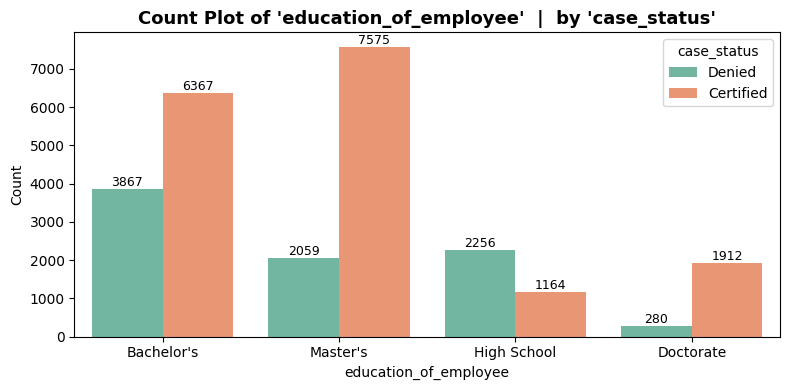


── 'education_of_employee' value counts ──
case_status            Certified  Denied
education_of_employee                   
Bachelor's                  6367    3867
Doctorate                   1912     280
High School                 1164    2256
Master's                    7575    2059



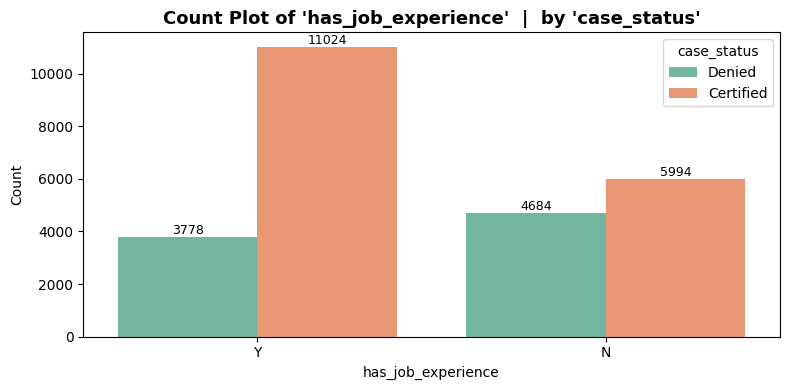


── 'has_job_experience' value counts ──
case_status         Certified  Denied
has_job_experience                   
N                        5994    4684
Y                       11024    3778



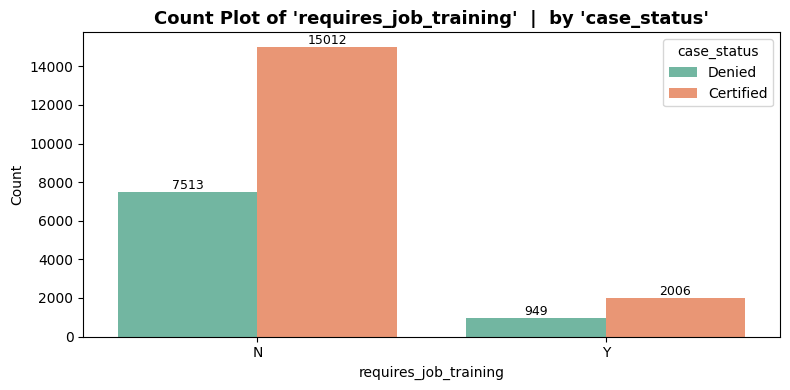


── 'requires_job_training' value counts ──
case_status            Certified  Denied
requires_job_training                   
N                          15012    7513
Y                           2006     949



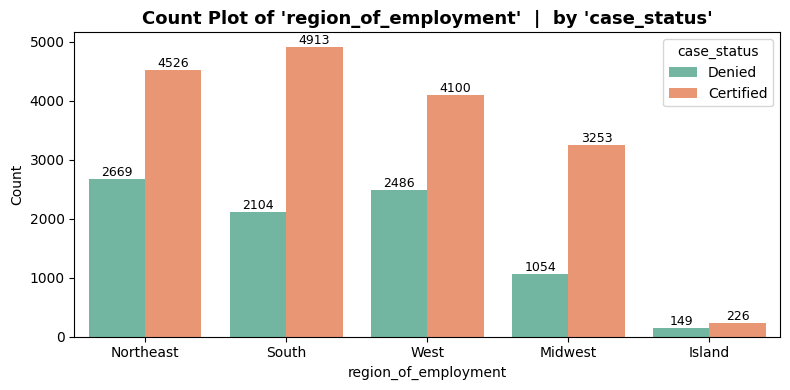


── 'region_of_employment' value counts ──
case_status           Certified  Denied
region_of_employment                   
Island                      226     149
Midwest                    3253    1054
Northeast                  4526    2669
South                      4913    2104
West                       4100    2486



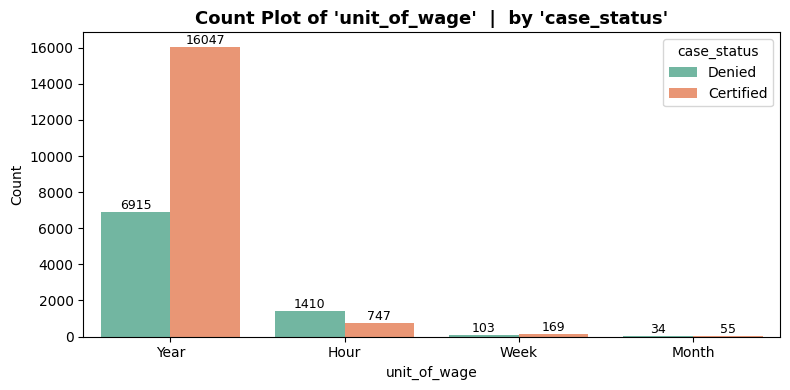


── 'unit_of_wage' value counts ──
case_status   Certified  Denied
unit_of_wage                   
Hour                747    1410
Month                55      34
Week                169     103
Year              16047    6915



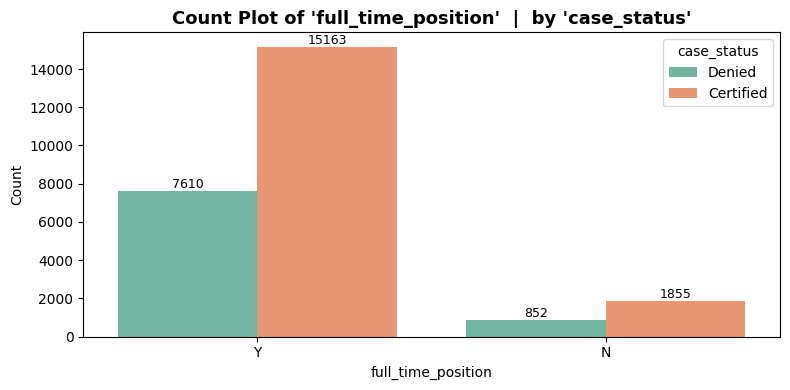


── 'full_time_position' value counts ──
case_status         Certified  Denied
full_time_position                   
N                        1855     852
Y                       15163    7610



In [78]:
# do labeled_barplot for all the columns
for col in cat_cols:
    plot_categorical(vd, col, hue='case_status')
    print()

# Observations on Categorical Variables:

- **continent:** The vast majority of applicants (66%) are from Asia, followed by Europe (15%) and North America (13%).

- **education_of_employee:** Nearly 78% of applicants hold either a Bachelor's (40%) or Master's (38%) degree. High School graduates make up ~13%, while Doctorate holders are the smallest group (9%).

- has_job_experience: A majority of the applicants (58%) possess prior job experience.

- requires_job_training: The clear majority (88%) do not require any job training.

- region_of_employment: Distribution across the major US regions is fairly balanced, with the Northeast (28%), South (28%), and West (26%) taking the lead, while the Midwest is lower (17%) and Islands are rare (1.5%).

- unit_of_wage: An overwhelming 90% of the prevailing wages are structured as a Yearly wage. Hour makes up about 8.5%, while Week and Month are negligible.

- full_time_position: Nearly 89% of the visa applications are for Full-Time positions.

- case_status (Target): About 67% of the cases in this dataset are Certified, while 33% are Denied (roughly a 2:1 ratio).

In [79]:
# ─────────────────────────────────────────────────────────────────────────────
# Function to do  Histogram  +  Box Plot for all  NUMERICAL columns
# ─────────────────────────────────────────────────────────────────────────────

def plot_numerical(
    data: pd.DataFrame,
    column: str,
    hue: str | None = None,
    bins: int = 30,
    color: str = "steelblue",
    palette: str = "Set2",
    kde: bool = False,
    figsize: tuple = (12, 4),
):
    """
    Histogram + Box Plot for a numerical column.

    Parameters
    ----------
    data    : DataFrame
    column  : Numerical column to plot
    hue     : Optional target column to split/colour plots by
    bins    : Histogram bin count
    color   : Bar colour when hue is None
    palette : Seaborn palette when hue is set
    kde     : Overlay KDE curve on histogram
    figsize : (width, height)
    """
    plot_data = data[[column] + ([hue] if hue else [])].dropna()

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(
        f"Distribution of '{column}'" + (f"  |  by '{hue}'" if hue else ""),
        fontsize=13, fontweight="bold",
    )

    # ── Histogram ──────────────────────────────────────────────────────────
    sns.histplot(
        data=plot_data, x=column,
        hue=hue, bins=bins, kde=kde,
        palette=palette if hue else None,
        color=color if not hue else None,
        edgecolor="white", ax=axes[0],
    )
    axes[0].set_title(f"Histogram{'  + KDE' if kde else ''}")
    skew_val = plot_data[column].skew()
    axes[0].text(
        0.97, 0.95, f"Skew: {skew_val:.2f}",
        transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
    )

    # ── Box Plot ───────────────────────────────────────────────────────────
    sns.boxplot(
        data=plot_data, x=hue, y=column,
        hue=hue, palette=palette if hue else None,
        color=color if not hue else None,
        legend=False, ax=axes[1],
    )
    axes[1].set_title("Box Plot")
    axes[1].set_xlabel(hue or "")

    plt.tight_layout()
    plt.show()

    # ── Summary stats ──────────────────────────────────────────────────────
    print(f"\n── '{column}' summary ──")
    if hue:
        print(plot_data.groupby(hue)[column].describe().round(2).to_string())
    else:
        print(plot_data[column].describe().round(2).to_string())


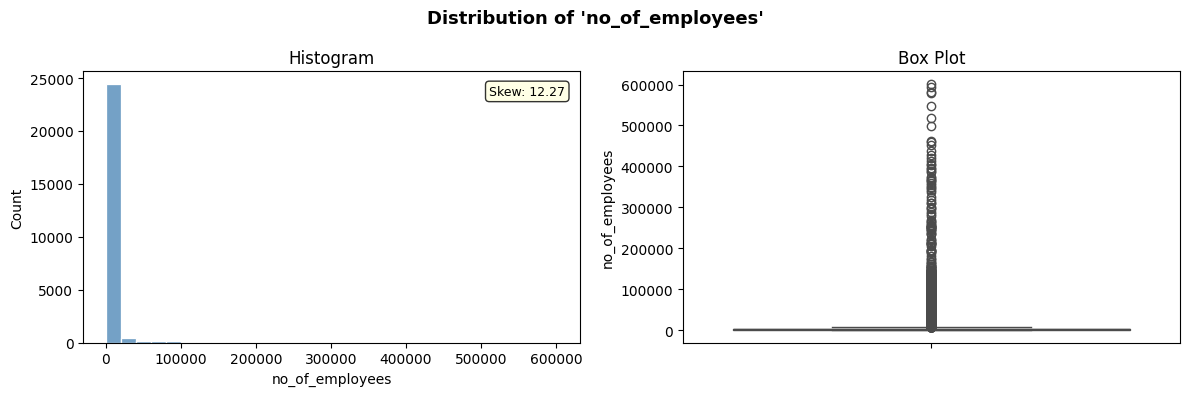


── 'no_of_employees' summary ──
count     25480.00
mean       5667.09
std       22877.92
min          11.00
25%        1022.00
50%        2109.00
75%        3504.00
max      602069.00


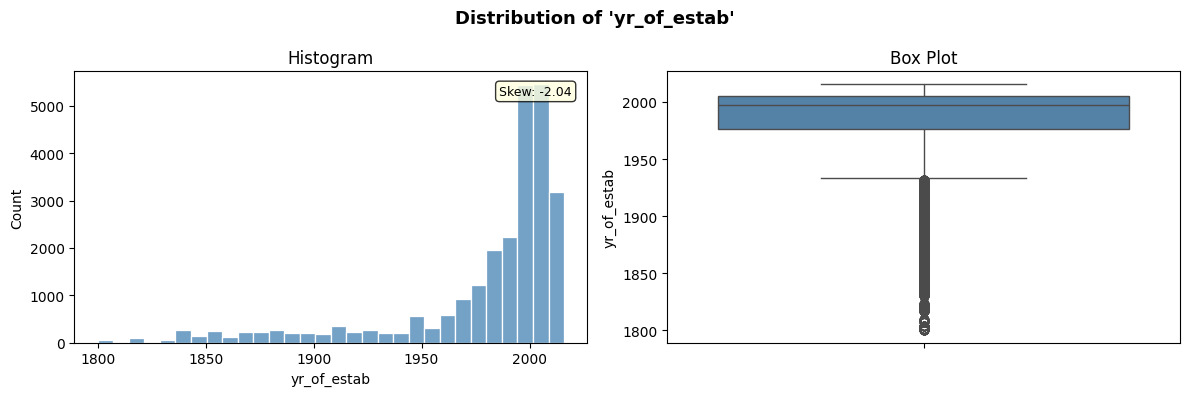


── 'yr_of_estab' summary ──
count    25480.00
mean      1979.41
std         42.37
min       1800.00
25%       1976.00
50%       1997.00
75%       2005.00
max       2016.00


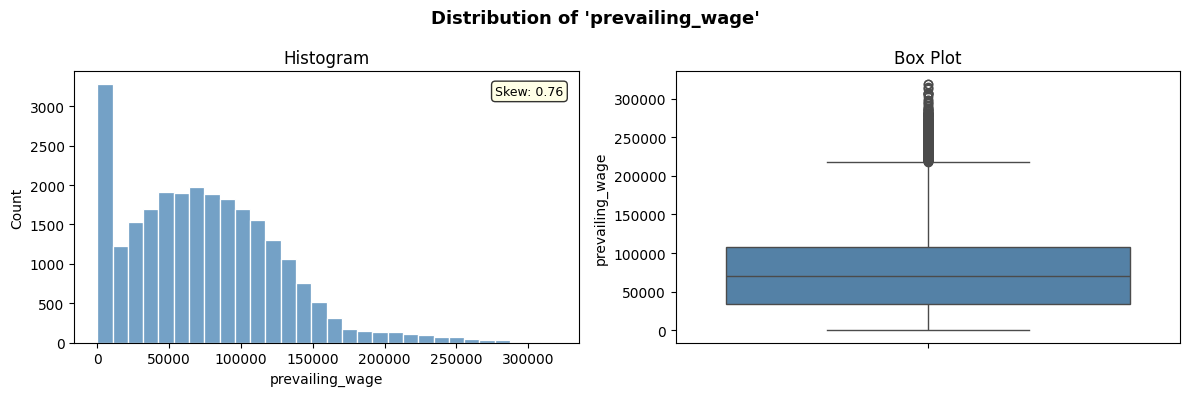


── 'prevailing_wage' summary ──
count     25480.00
mean      74455.81
std       52815.94
min           2.14
25%       34015.48
50%       70308.21
75%      107735.51
max      319210.27


In [80]:
    # ── Numerical examples ─────────────────────────────────────────────────
for col in ["no_of_employees", "yr_of_estab", "prevailing_wage"]:
  plot_numerical(vd, col)

# Observations on Numerical Variables:

- no_of_employees: Highly right-skewed. The median company size is 2,109 employees, but the extreme maximum stretches to 602,069, showing that the data includes a few massive corporate giants alongside typical mid-sized employers.

- yr_of_estab: Heavily left-skewed toward modern establishments. While company ages range back to 1800, 75% of the companies in the dataset were founded after 1976, and 50% after 1997.

- prevailing_wage: Shows massive variance (ranging from 2.14 to 319,210.27). This is primarily driven by the fact that unit_of_wage mixes hourly rates with annual salaries, need to standardize this column before modeling.

# Bivariate Analysis

In [81]:
# ==============================================================================
# # Bivariate Analysis
# ==============================================================================
def stacked_barplot(data, predictor, target):
    """
    Plots a 100% normalized stacked bar chart with clean, readable percentage labels.
    """
    # 1. Generate cross-tabulation normalized by row index
    tab = pd.crosstab(data[predictor], data[target], normalize="index") * 100

    # 2. Plot the dataframe directly as a stacked bar chart
    ax = tab.plot(kind="bar", stacked=True, figsize=(10, 5), color=['#2ecc71', '#e74c3c'])

    # 3. Add clean percentage labels centered inside the bar segments safely
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()

        # Only display text if the segment is larger than 5% to prevent overlapping clutter
        if height > 5.0:
            ax.annotate(
                f'{height:.1f}%',
                (x + width/2, y + height/2),
                ha='center',
                va='center',
                color='white',
                fontweight='bold',
                fontsize=9
            )

    plt.legend(title=target, loc="upper left", bbox_to_anchor=(1, 1))
    plt.ylabel("Percentage (%)")
    plt.xlabel(predictor)
    plt.title(f"Distribution of {target} by {predictor}", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_bivariate_numeric(data, col_x, col_y, hue=None, figsize=(10, 6)):
    """
    Plots standard scatter distributions for numerical combinations or clean boxplots
    against the target without deceptive population-relative percentages.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Numerical vs Numerical -> Scatter Plot
    if pd.api.types.is_numeric_dtype(data[col_x]) and pd.api.types.is_numeric_dtype(data[col_y]):
        sns.scatterplot(data=data, x=col_x, y=col_y, hue=hue, palette="Set1", alpha=0.6, ax=ax)
        corr = data[[col_x, col_y]].corr().iloc[0, 1]
        ax.text(0.97, 0.05, f"r = {corr:.2f}", transform=ax.transAxes, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        ax.set_title(f"Scatter: '{col_x}' vs '{col_y}'" + (f" | by '{hue}'" if hue else ""))

    # Categorical vs Numerical -> Clean Boxplot split by Target
    else:
        cat_col, num_col = (col_x, col_y) if not pd.api.types.is_numeric_dtype(data[col_x]) else (col_y, col_x)
        sns.boxplot(data=data, x=cat_col, y=num_col, hue=hue, palette="Set2", ax=ax)
        ax.set_title(f"Distribution of '{num_col}' across '{cat_col}'")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

def plot_bivariate_all(data, target, num_cols, cat_cols, extra_pairs=None):
    """
    Orchestrates the entire Bivariate Analysis phase in three clean passes.
    """
    # Categorical Features vs Target ──
    print("━" * 60)
    print(f" Categorical Features vs Target: '{target}'")
    print("━" * 60)
    for col in cat_cols:
        if col != target:
            stacked_barplot(data, col, target)

    # Numerical Features vs Target ──
    print("━" * 60)
    print(f" Numerical Features vs Target: '{target}'")
    print("━" * 60)
    for col in num_cols:
        if col != target:
            fig, ax = plt.subplots(figsize=(10, 5))
            sns.boxplot(data=data, x=target, y=col, hue=target, palette="Set2", ax=ax)
            ax.set_title(f"Distribution of {col} by {target}", fontweight='bold')
            plt.show()

    # Selected Feature-to-Feature Pairs ──
    if extra_pairs:
        print("━" * 60)
        print(" Selected Feature-to-Feature Pairs")
        print("━" * 60)
        for col_x, col_y in extra_pairs:
            # Route 1: Numeric vs Numeric -> Scatter plot
            if col_x in num_cols and col_y in num_cols:
                plot_bivariate_numeric(data, col_x, col_y, hue=target)
            # Route 2: Mixed Type -> Boxplot
            elif col_x in num_cols or col_y in num_cols:
                plot_bivariate_numeric(data, col_x, col_y, hue=target)
            # Route 3: Categorical vs Categorical -> Cross Stacked Bar Plot
            else:
                stacked_barplot(data, col_x, col_y)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Categorical Features vs Target: 'case_status'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


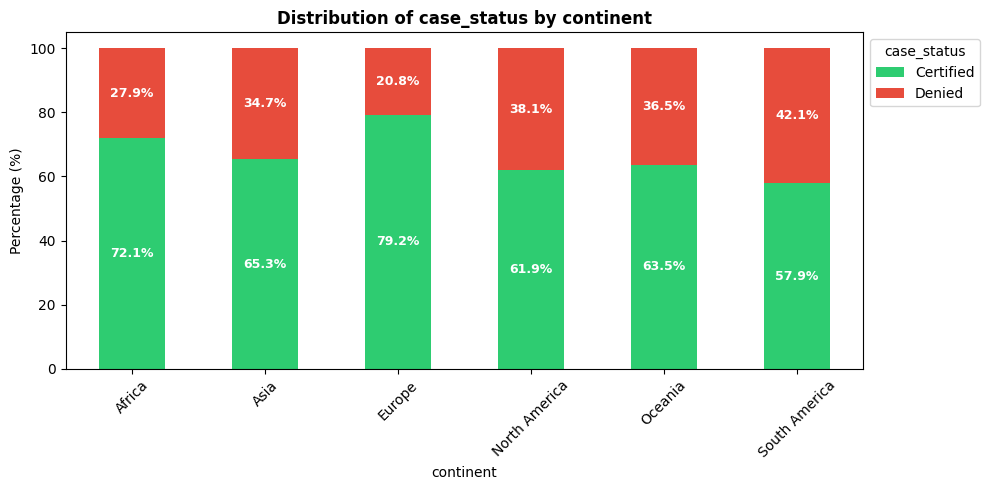

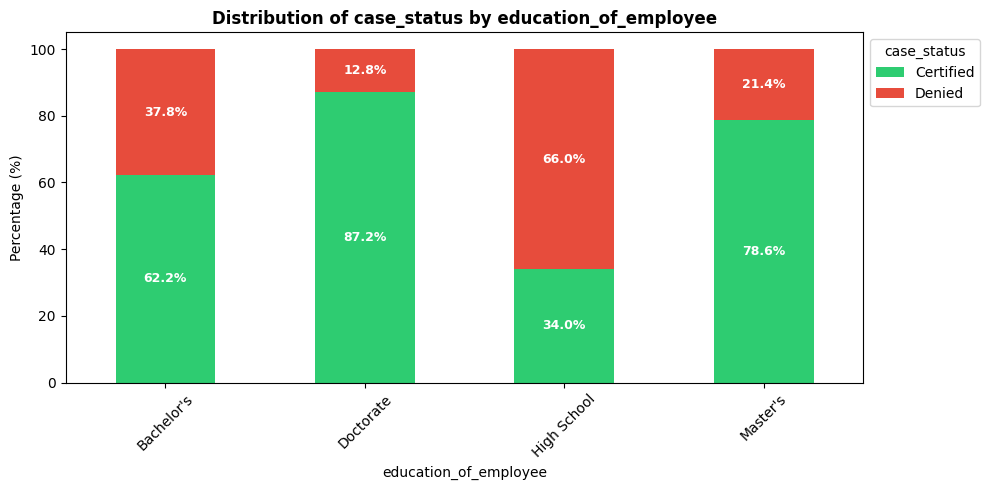

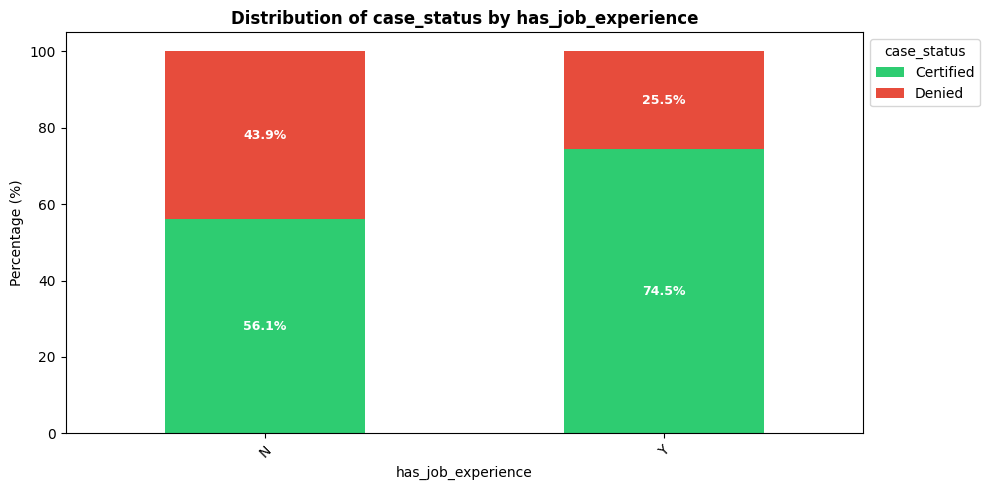

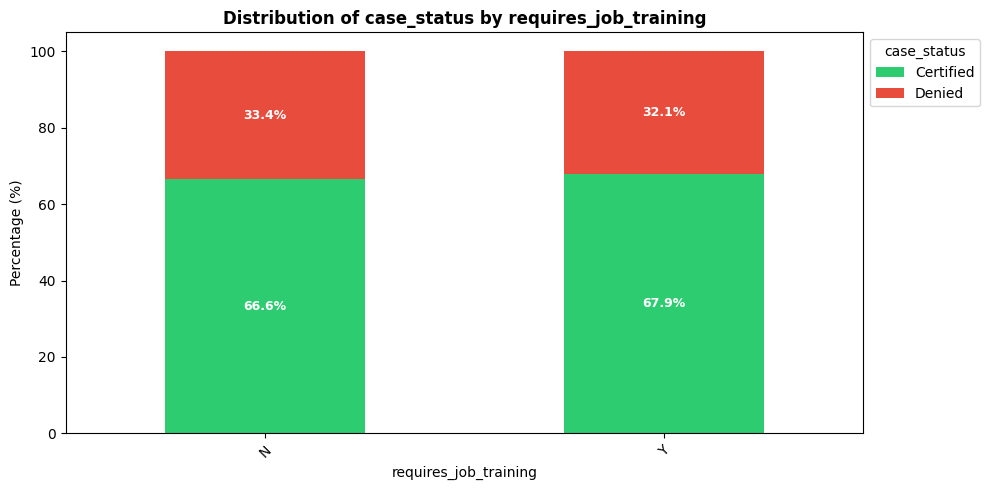

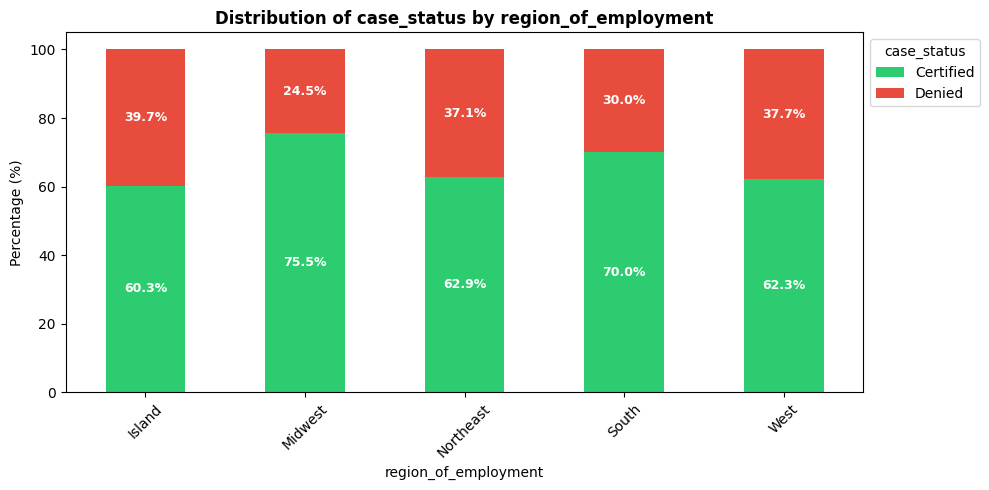

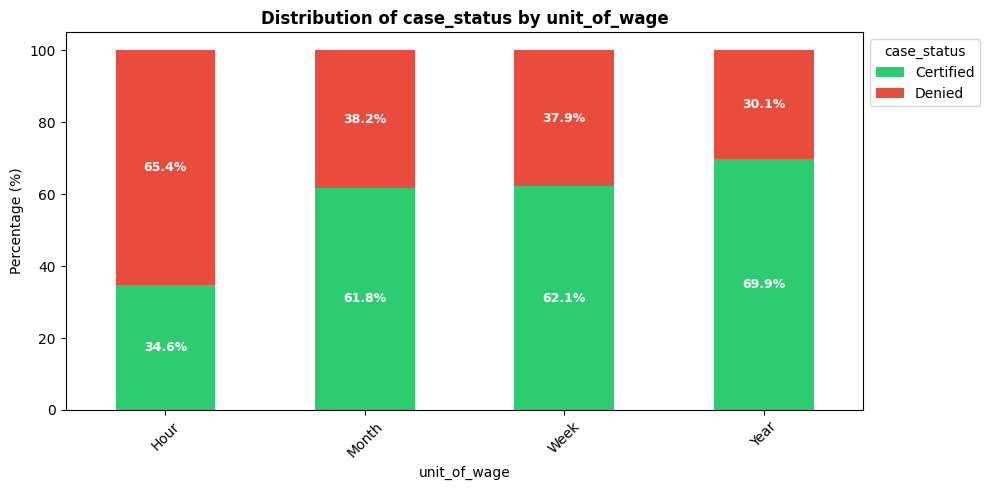

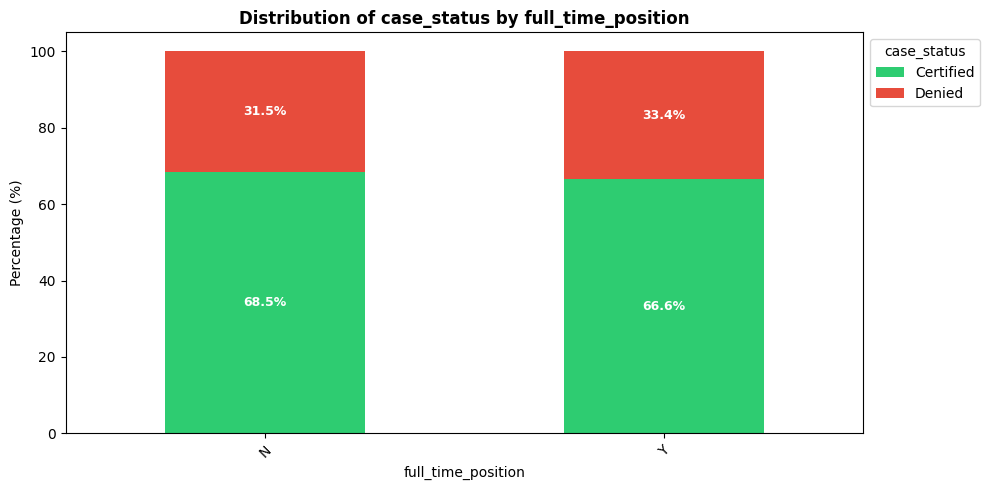

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Numerical Features vs Target: 'case_status'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


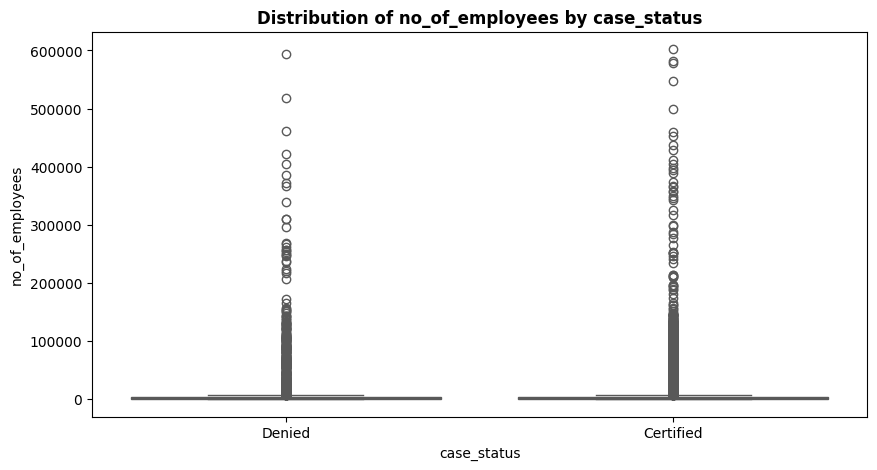

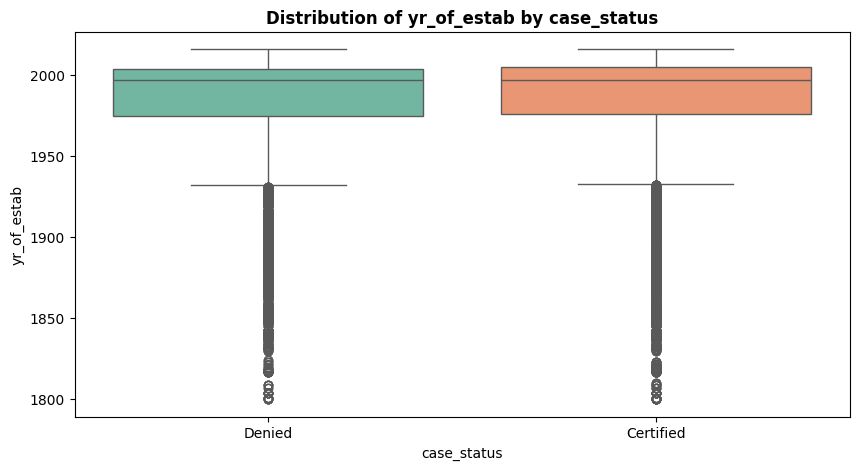

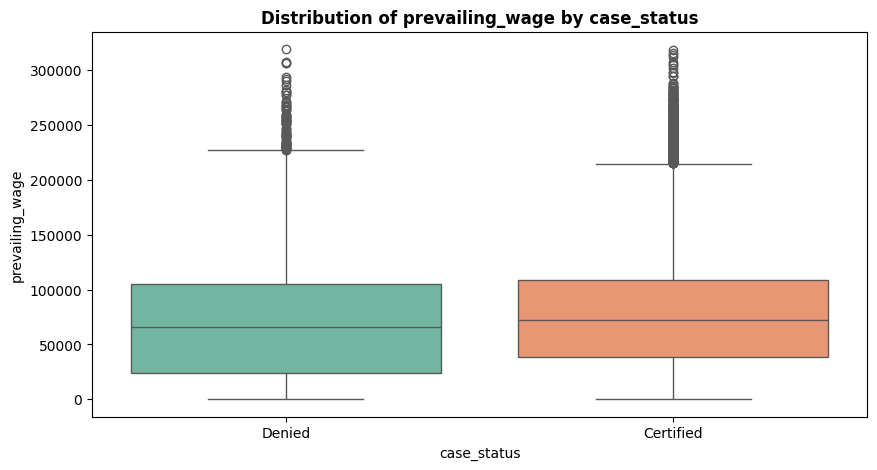

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Selected Feature-to-Feature Pairs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


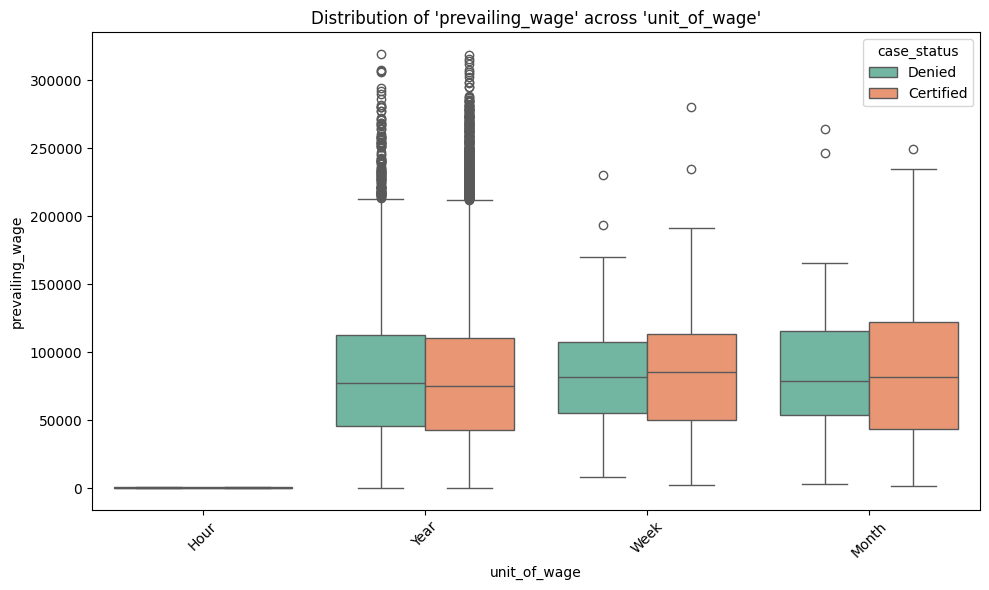

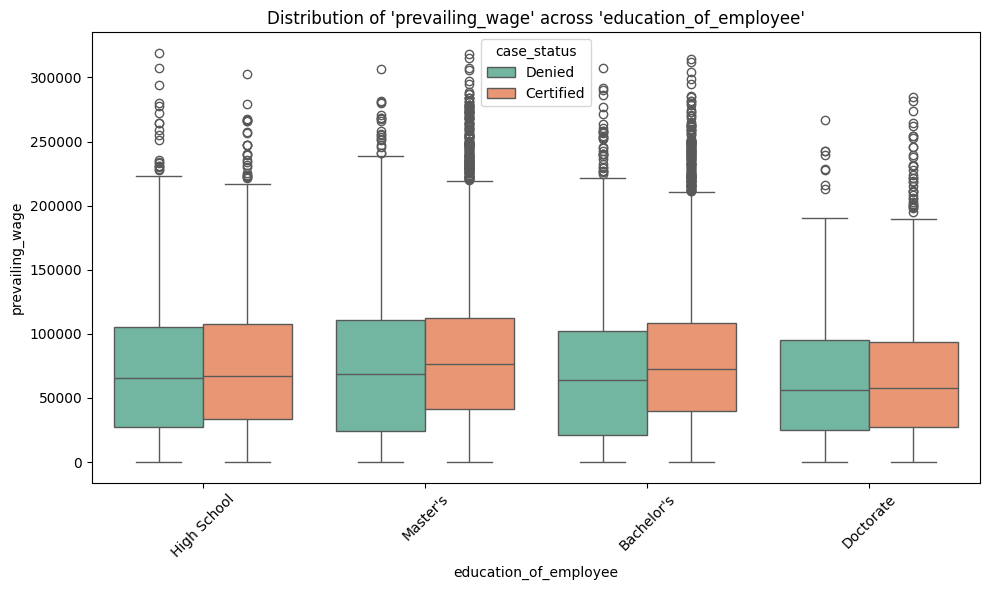

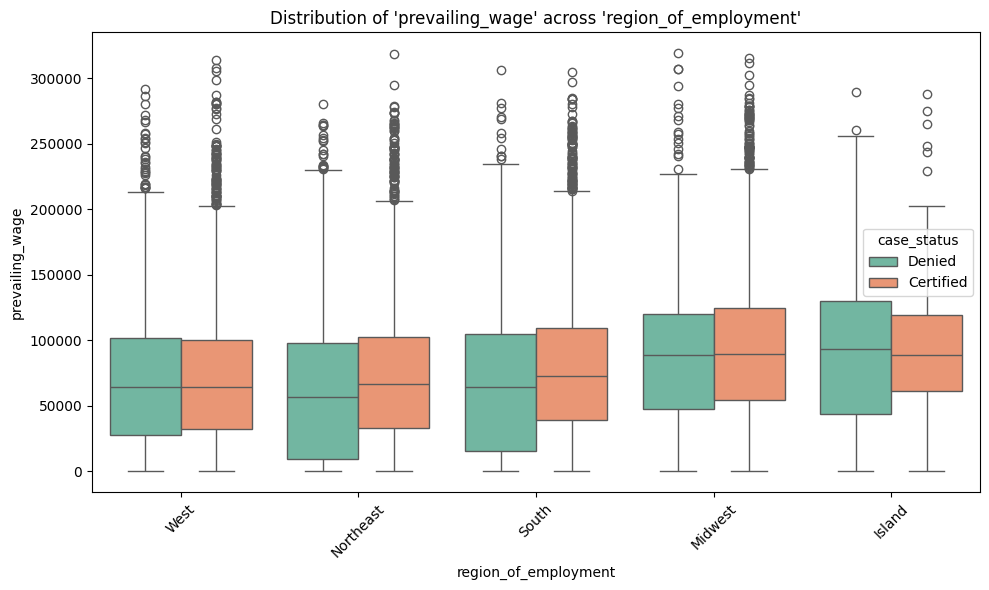

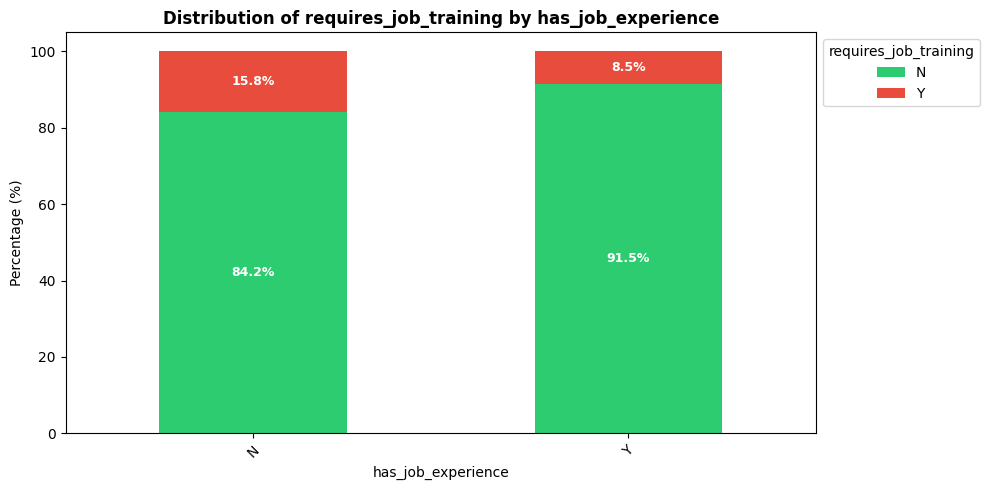

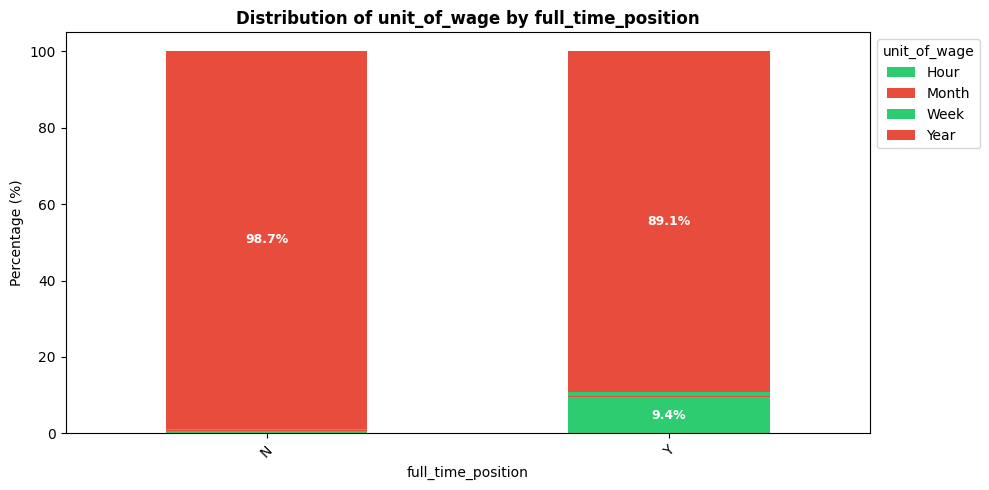

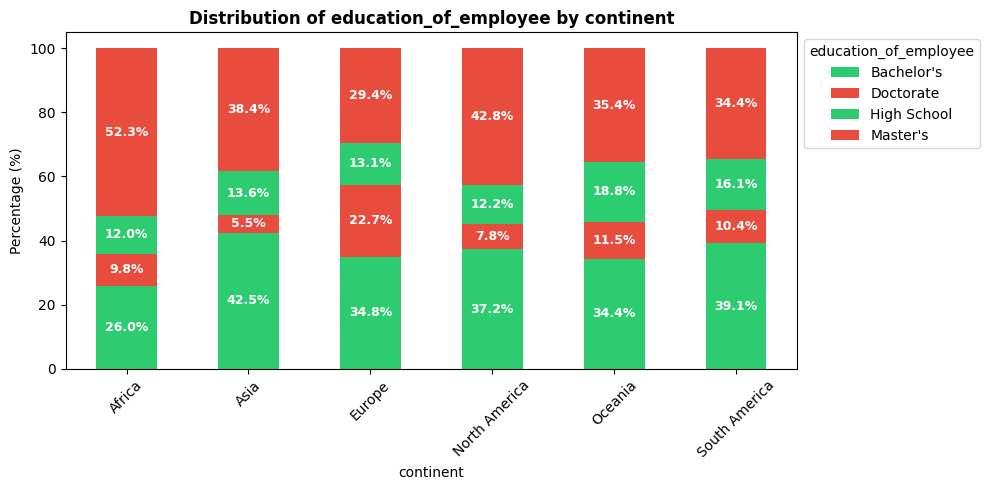

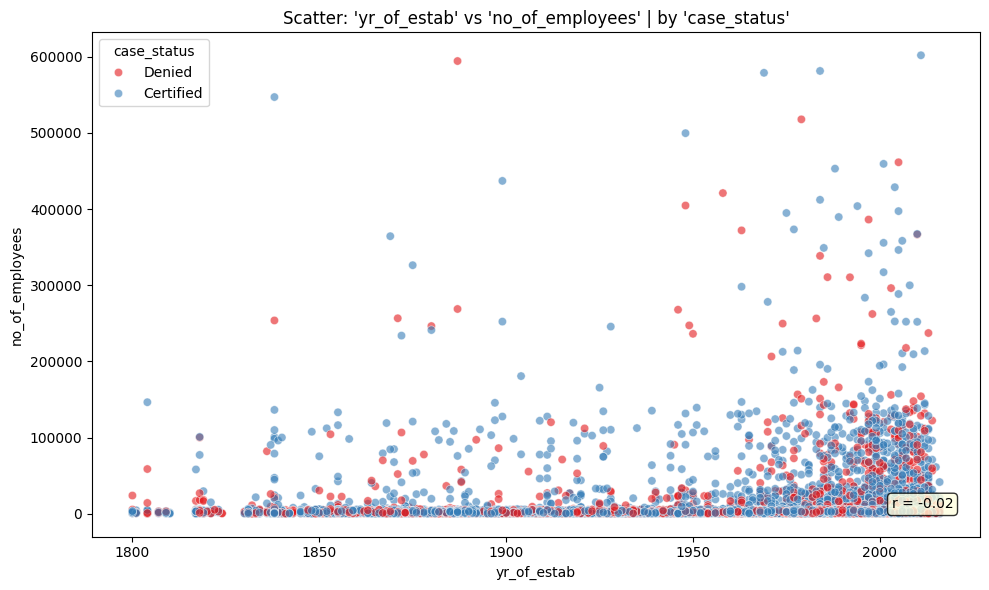

In [82]:
# ── RUNNING THE CLEAN BIVARIATE ANALYSIS ──
# Define parameters
target_var = "case_status"
numerical_features = ["no_of_employees", "yr_of_estab", "prevailing_wage"]
categorical_features = [c for c in cat_cols if c != target_var]

feature_pairs = [
    ("unit_of_wage", "prevailing_wage"),
    ("education_of_employee", "prevailing_wage"),
    ("region_of_employment", "prevailing_wage"),
    ("has_job_experience", "requires_job_training"),
    ("full_time_position", "unit_of_wage"),
    ("continent", "education_of_employee"),
    ("yr_of_estab", "no_of_employees")
]

# Run the pipeline
plot_bivariate_all(
    data=vd,
    target=target_var,
    num_cols=numerical_features,
    cat_cols=categorical_features,
    extra_pairs=feature_pairs
)

# Bivariate Analysis Observations:

## Categorical vs. Target (case_status)
- Education: Doctorate (87% approval) and Master's degrees drive success; High School grads are mostly denied (66%).

- Experience: Prior job experience raises approvals significantly (74% vs 56%).

- Wage Unit: Hourly positions are mostly denied (65%); Yearly salaries enjoy high approval (70%).

- Region / Full-Time: Minimal impact; approval ratios stay close to the baseline 2:1 average.

- Continent: Europe has the highest approval rate (79%), while Asia dominates total volume.

## Numerical vs. Target
- Company Size: Overlapping spreads show large size companies do not guarantee higher approval rates than small companies.

- Company Age: Founding year distributions are nearly identical for certified and denied cases, showing zero impact.

# Multivariate Analysis

In [83]:
# ==============================================================================
# # Multivariate Analysis
# ==============================================================================

def plot_correlation(data, columns=None, method="pearson", cmap="coolwarm", figsize=(10, 8)):
    """
    Plots a clean, lower-triangle correlation heatmap for numerical columns.
    """
    num_data = data[columns] if columns else data.select_dtypes(include="number")
    num_data = num_data.dropna()

    corr_matrix = num_data.corr(method=method)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,
        vmin=-1, vmax=1, linewidths=0.5, square=True,
        annot_kws={"size": 10}, ax=ax
    )
    ax.set_title(f"Correlation Matrix ({method.capitalize()})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_pairplot(data, columns, hue=None, palette="Set1", figsize=(12, 12)):
    """
    Plots a pairwise relationship grid across numerical features stratified by a target hue.
    """
    use_cols = columns + ([hue] if hue and hue not in columns else [])
    plot_data = data[use_cols].dropna()

    g = sns.pairplot(
        plot_data, vars=columns, hue=hue, palette=palette,
        diag_kind="kde", kind="scatter",
        plot_kws={"alpha": 0.4, "s": 15}, # cleaner, less crowded scatter points
        height=figsize[1] / len(columns)
    )
    g.figure.suptitle(f"Pair Plot" + (f" | by '{hue}'" if hue else ""), y=1.02, fontsize=13, fontweight="bold")
    plt.show()


def plot_multivariate_all(data, num_cols, target=None):
    """
    Orchestrates the Multivariate Analysis phase.
    """
    print("━" * 60)
    print(" Numeric Feature Linear Correlations")
    print("━" * 60)
    plot_correlation(data, columns=num_cols)

    print("━" * 60)
    print(f" Pairwise Feature Interactions Stratified by '{target}'")
    print("━" * 60)
    plot_pairplot(data, columns=num_cols, hue=target)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Numeric Feature Linear Correlations
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


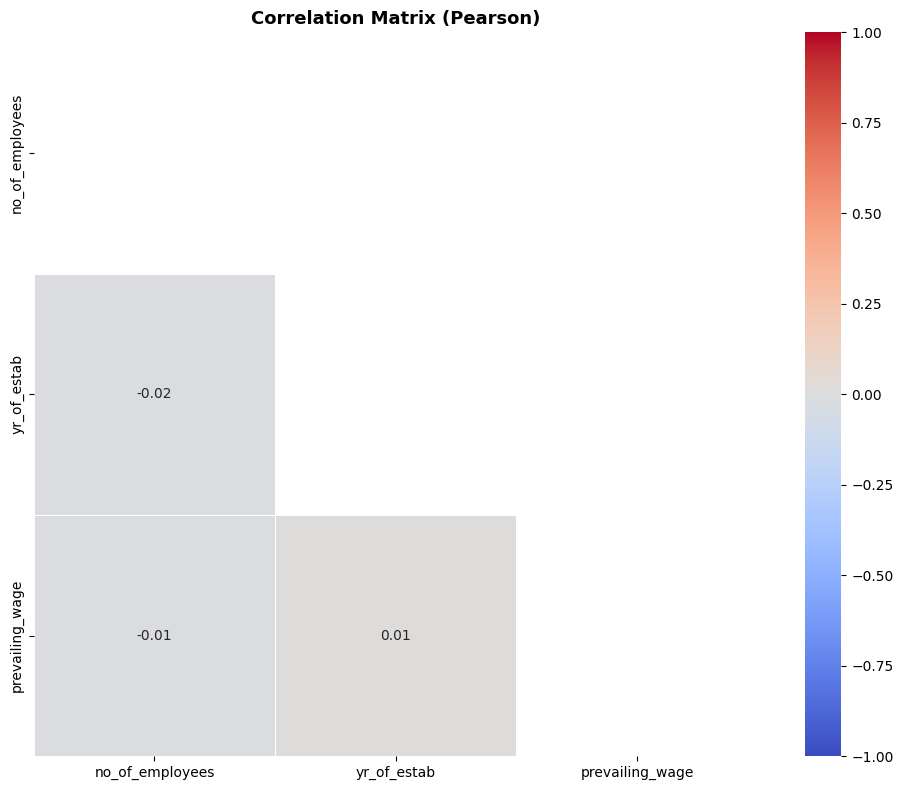

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Pairwise Feature Interactions Stratified by 'case_status'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


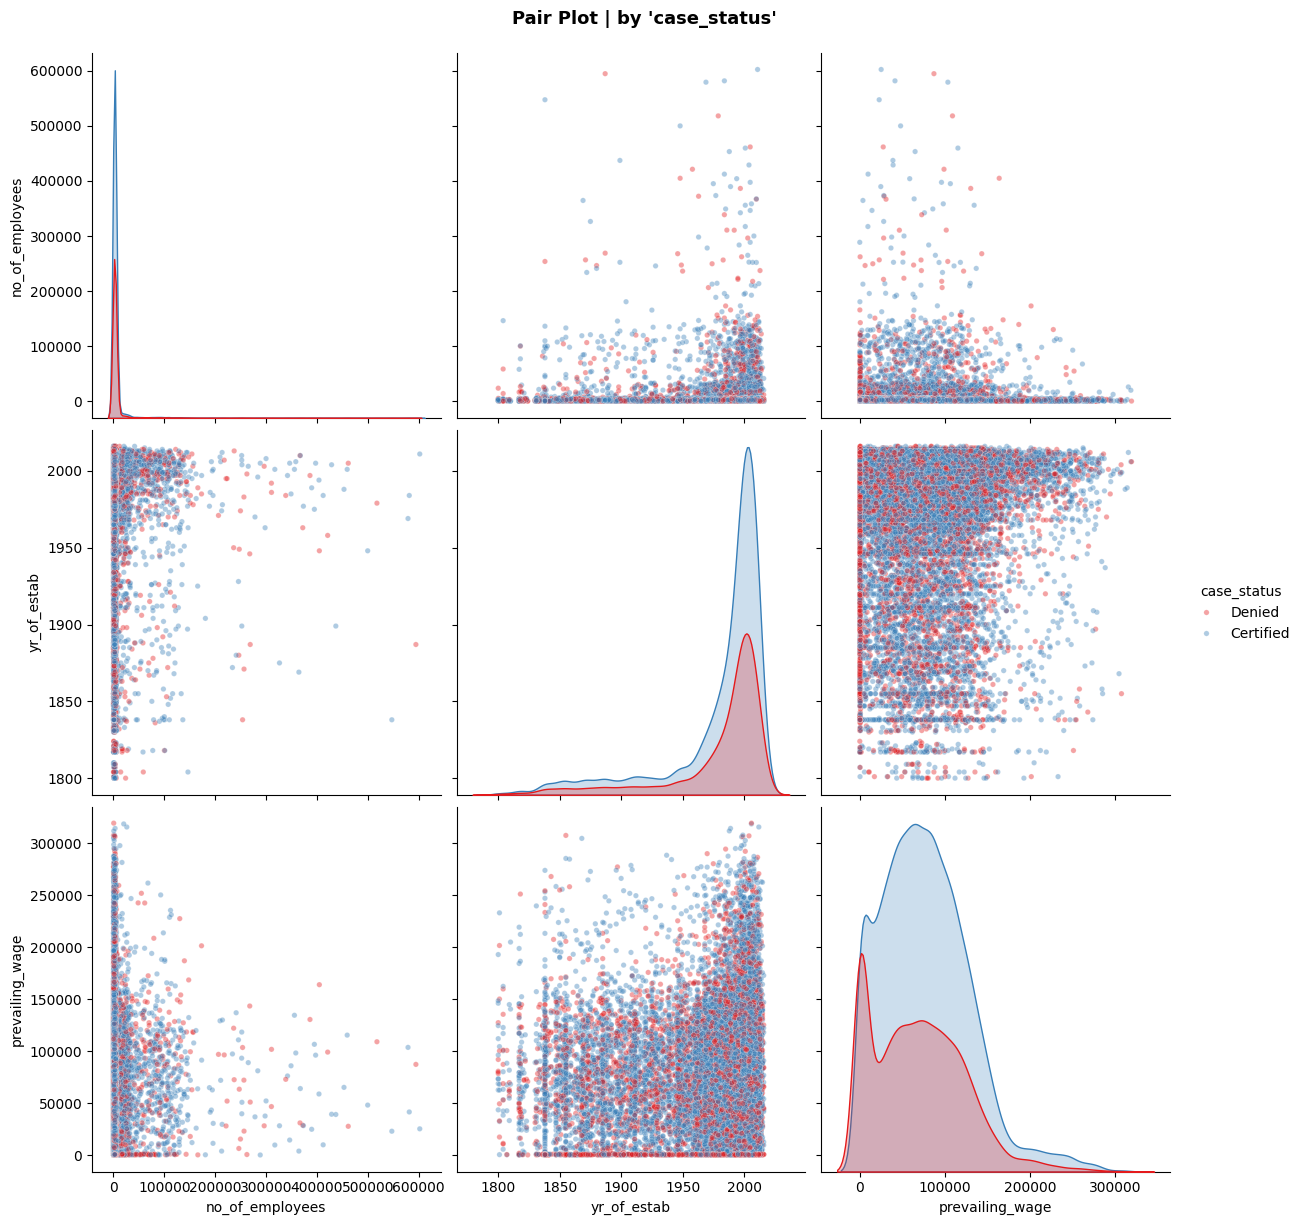

In [84]:
# Run the pipeline
plot_multivariate_all(data=vd, num_cols=numerical_features, target=target_var)

# Multivariate Analysis observations

* **Feature Independence:** No distinct clusters or linear paths exist when combining `no_of_employees`, `yr_of_estab`, and `prevailing_wage` The correlation coefficient is approximately equal to zero.
* **Target Segregation:** Certified (blue) and Denied (red) data points overlap completely across all numerical spaces, showing that numerical combinations alone cannot separate the two classes.
* **Wage Dominance:** High prevailing wages show a dense, compressed vertical spread against both company age and employee count, highlighting variance but no clear multi-variable boundaries.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

Observations:
Lets make understand what updates we need to do from above data;
no_of_employees was already taken care above.
1.  yr_of_estab can be moved to 'company_age'
2. prevaling_wage: different unit_of_wage, Hour, weekly, monthly based rates need to be scaled to Year
3. prevaling_wage:   Year also have min as 100 !! on checking there are 110 such records which are pointing less than 1000$ per year which could be a data entry problems, so impute them to mean salary
4. convert the target variable case_status to numerical 0 and 1
5. Encode the Education history as well


In [85]:

import datetime

# 1. Calculate company age dynamically using the current calendar year
current_year = datetime.datetime.now().year
vd['company_age'] = current_year - vd['yr_of_estab']
vd.drop('yr_of_estab', axis=1, inplace=True)

# 2. Harmonize ALL wage units to a strict Annual baseline scale
def annualize_wage(row):
    if row['unit_of_wage'] == 'Hourly':
        return row['prevailing_wage'] * 40 * 52  # 40 hours/week, 52 weeks
    elif row['unit_of_wage'] == 'Weekly':
        return row['prevailing_wage'] * 52       # 52 weeks
    elif row['unit_of_wage'] == 'Monthly':
        return row['prevailing_wage'] * 12       # 12 months
    else:
        return row['prevailing_wage']            # Already Yearly

vd['prevailing_wage'] = vd.apply(annualize_wage, axis=1)
vd.drop('unit_of_wage', axis=1, inplace=True)  # Safe to drop now that scales match!

# 3. Handle the 110 low-wage anomalies by imputing with the clean median
valid_median = vd[vd['prevailing_wage'] >= 10000]['prevailing_wage'].median()
vd['prevailing_wage'] = vd['prevailing_wage'].apply(lambda x: valid_median if x < 10000 else x)

# 4. Target Encode (Certified = 1, Denied = 0)
vd['case_status'] = vd['case_status'].apply(lambda x: 1 if x == "Certified" else 0)

# 5. encoding Education hierarchy explicitly
dict_edu = {"High School": 0, "Bachelor's": 1, "Master's": 2, "Doctorate": 3}
vd['education_of_employee'] = vd['education_of_employee'].map(dict_edu)


In [86]:
# Split the data to Target variable
X = vd.drop(["case_status"], axis=1)
y = vd["case_status"]

# One-Hot Encode remaining nominal variables (continent, region, training, experience, position)
X = pd.get_dummies(X, drop_first=True)

In [87]:
#  Perform Stratified Splits (80/20 then 75/25) to preserve class distributions
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [88]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 16)
Shape of the Validation set:  (5096, 16)
Shape of test set :  (5096, 16)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


# **Model Building**

## Model Evaluation Pointers:

Firstly, lets try to understand the imapct of the model predection between False Positives and False Negatives
False Positives: Predicting a visa will be certified when it should be denied. (Result: A company hires an unqualified worker; a US citizen misses a job opportunity).

False Negatives: Predicting a visa will be denied when it should be certified. (Result: The company/US economy loses out on critical talent).

Because both errors cause distinct corporate and economic damage, optimizing for F1-Score would be the correct strategy. It calculates the harmonic mean of Precision and Recall, forcing the model to minimize both types of misclassifications simultaneously.

In [89]:
"""
Definition: Evaluates a trained model across an arbitrary number of datasets.
Usage: model_eval(model, "Random Forest", Train=(X_train, y_train), Val=(X_val, y_val))
"""
def model_eval(model, name, **datasets):
    perf_records = []

    for phase_name, (X, y) in datasets.items():
        preds = model.predict(X)
        perf_records.append({
            "Model Name": name,
            "Phase": phase_name,
            "Accuracy": metrics.accuracy_score(y, preds),
            "Recall": metrics.recall_score(y, preds),
            "Precision": metrics.precision_score(y, preds),
            "F1": metrics.f1_score(y, preds)
        })

    return pd.DataFrame(perf_records)

In [90]:
"""
Definition: Dynamically creates side-by-side confusion matrix subplots for all passed phases.

Usage: plot_confusion_matrix(model, "Random Forest", Train=(X_train, y_train), Val=(X_val, y_val))
"""
def plot_confusion_matrix(model, name, **datasets):
    num_phases = len(datasets)
    fig, axes = plt.subplots(1, num_phases, figsize=(5 * num_phases, 4))
    fig.suptitle(f"Confusion Matrices for {name}", fontsize=12, fontweight='bold')

    # Ensure axes is always iterable even if only 1 dataset is passed
    if num_phases == 1:
        axes = [axes]

    for ax, (phase_name, (X, y)) in zip(axes, datasets.items()):
        metrics.ConfusionMatrixDisplay.from_estimator(
            model, X, y, ax=ax, cmap='Blues' if 'train' in phase_name.lower() else 'Oranges', colorbar=False
        )
        ax.set_title(f"{phase_name} Performance")

    plt.tight_layout()
    plt.show()

## Model Building - Basic

In [91]:
def build_models(X_train, y_train, X_val, y_val):
  # first build very basic models and we can tune that later
  model_list = []

  # Append each model and its names
  model_list.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
  model_list.append(("Bagging", BaggingClassifier(random_state=1)))
  model_list.append(("Random Forest", RandomForestClassifier(random_state=1)))
  model_list.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
  model_list.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
  model_list.append(("XGBoost", XGBClassifier(random_state=1)))

  # List to hold individual evaluation dataframes for the final table
  summary_list = []

  # Train the models with actual X_train data and Validation data
  print("Train Model & check Performance:\n")
  for name, model in model_list:
      # 1. Fit the model once
      model.fit(X_train, y_train)

      # 2. Evaluate performance across both phases seamlessly
      perf_df = model_eval(model, name, Train=(X_train, y_train), Val=(X_val, y_val))
      summary_list.append(perf_df)

      # Print individual block headers matching
      print("="*60)
      print(f"MODEL RUNNING: {name}")
      print("="*60)
      display(perf_df)

      # 3. Plot matrices side-by-side automatically
      plot_confusion_matrix(model, name, Train=(X_train, y_train), Val=(X_val, y_val))
      print("-" * 50)

  # --- Tabular Summary Section ---
  print("\n" + "="*80)
  print("                       FINAL PERFORMANCE SUMMARY TABLE")
  print("="*80)

  # Vertically stack all collected dataframes at once
  df_results = pd.concat(summary_list, ignore_index=True)
  display(df_results.round(4))
  return model_list

Train Model & check Performance:

MODEL RUNNING: Decision Tree


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Decision Tree,Train,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,Val,0.647567,0.717685,0.745272,0.731218


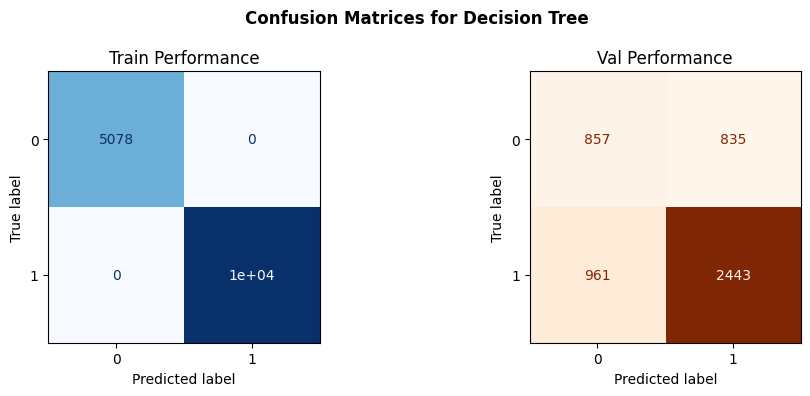

--------------------------------------------------
MODEL RUNNING: Bagging


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Bagging,Train,0.984759,0.985798,0.991333,0.988558
1,Bagging,Val,0.690738,0.764689,0.770574,0.767620


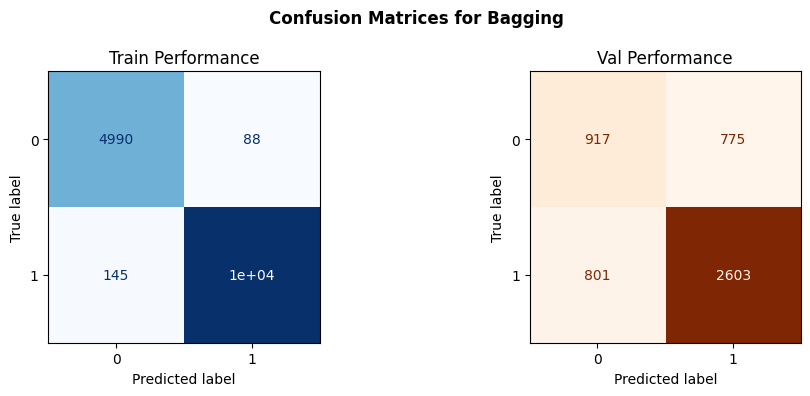

--------------------------------------------------
MODEL RUNNING: Random Forest


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Random Forest,Train,1.000000,1.00000,1.000000,1.000000
1,Random Forest,Val,0.714089,0.83255,0.761623,0.795509


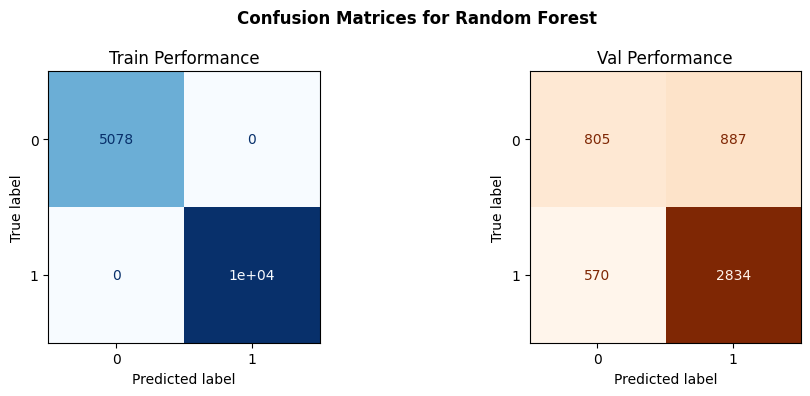

--------------------------------------------------
MODEL RUNNING: Gradient Boosting


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Gradient Boosting,Train,0.751962,0.88237,0.776638,0.826135
1,Gradient Boosting,Val,0.747253,0.87691,0.774520,0.822541


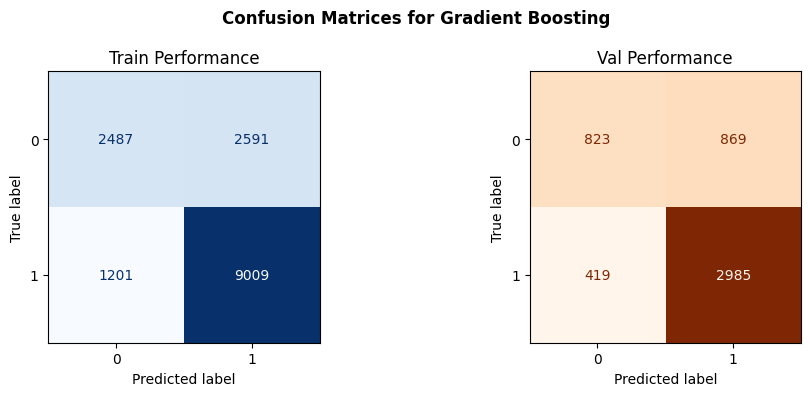

--------------------------------------------------
MODEL RUNNING: AdaBoost


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,AdaBoost,Train,0.736133,0.891185,0.756862,0.818550
1,AdaBoost,Val,0.732143,0.881904,0.757125,0.814765


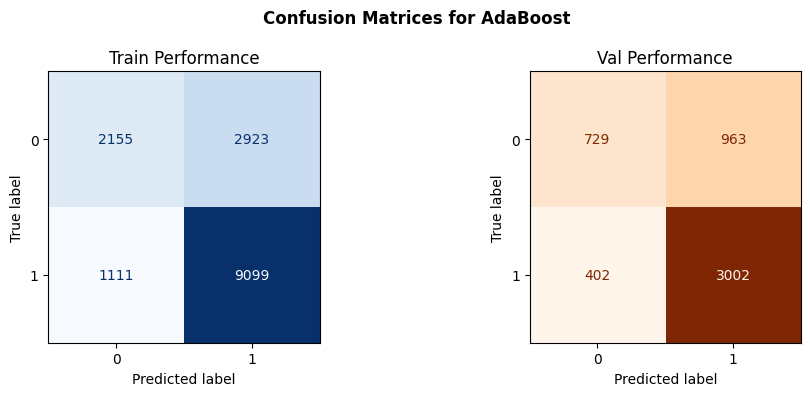

--------------------------------------------------
MODEL RUNNING: XGBoost


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,XGBoost,Train,0.851125,0.932517,0.857130,0.893236
1,XGBoost,Val,0.727237,0.848120,0.767819,0.805974


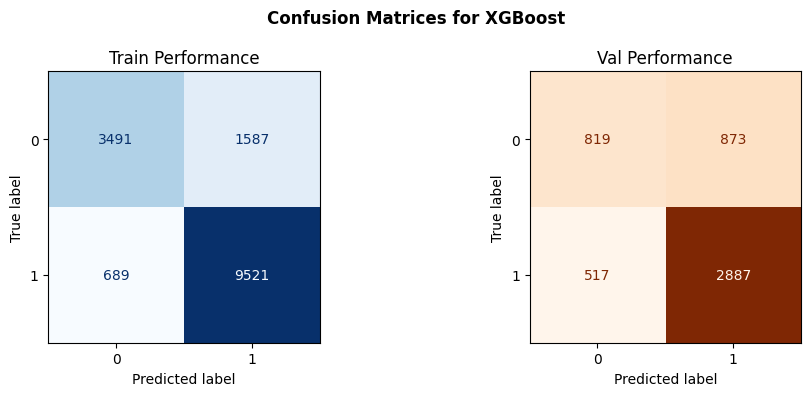

--------------------------------------------------

                       FINAL PERFORMANCE SUMMARY TABLE


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Decision Tree,Train,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,Val,0.6476,0.7177,0.7453,0.7312
2,Bagging,Train,0.9848,0.9858,0.9913,0.9886
3,Bagging,Val,0.6907,0.7647,0.7706,0.7676
4,Random Forest,Train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,Val,0.7141,0.8325,0.7616,0.7955
6,Gradient Boosting,Train,0.7520,0.8824,0.7766,0.8261
7,Gradient Boosting,Val,0.7473,0.8769,0.7745,0.8225
8,AdaBoost,Train,0.7361,0.8912,0.7569,0.8185
9,AdaBoost,Val,0.7321,0.8819,0.7571,0.8148


In [92]:
#Lets build basic models with prepared data
basic_model_list = build_models(X_train, y_train, X_val, y_val)

Observations:
- **Severe Overfitting (Decision Tree & Random Forest)**: Both achieve perfect training scores ($1.0000$ F1) but drop drastically on validation data, showing they are memorizing the training set instead of learning patterns.
- **Moderate Overfitting (Bagging)**: Performs strong on training ($0.9886$ F1) but suffers a significant performance drop on validation ($0.7676$ F1).
- **Best Generalization (AdaBoost & XGBoost)**: These models show the closest gap between training and validation scores. They resist overfitting effectively and generalize the best to unseen data.
- **Top Performer (XGBoost)**: Delivers the highest overall validation metrics across the board, making it the primary champion candidate before hyperparameter tuning.

## Model Building - Oversampled Data

In [93]:
#lets do oversampling to get our under represented denied case_status target vairable

#print case_status variable accepted vs denied count before oversampling
print("y_train Actual: ",y_train.value_counts())
print("Shape of Training set Actual: ", X_train.shape)

#oversampling

smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

#print case_status variable accepted vs denied count after oversampling
print("y_train oversampled: ",y_train_over.value_counts())
print("Shape of Training set oversampled: ", X_train_over.shape)

y_train Actual:  case_status
1    10210
0     5078
Name: count, dtype: int64
Shape of Training set Actual:  (15288, 16)
y_train oversampled:  case_status
0    10210
1    10210
Name: count, dtype: int64
Shape of Training set oversampled:  (20420, 16)


Train Model & check Performance:

MODEL RUNNING: Decision Tree


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Decision Tree,Train,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,Val,0.644819,0.710047,0.745988,0.727574


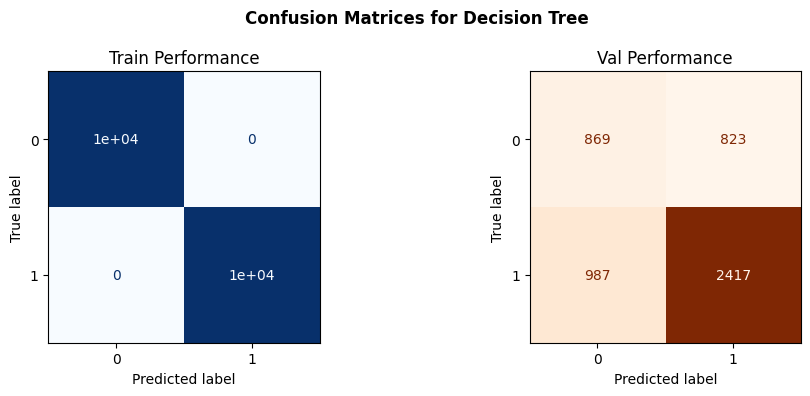

--------------------------------------------------
MODEL RUNNING: Bagging


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Bagging,Train,0.987218,0.981783,0.992574,0.987149
1,Bagging,Val,0.686617,0.748237,0.774871,0.761321


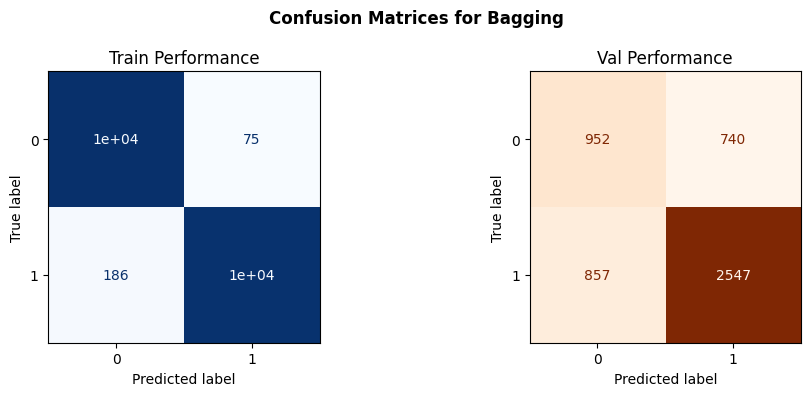

--------------------------------------------------
MODEL RUNNING: Random Forest


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Random Forest,Train,1.000000,1.000000,1.00000,1.000000
1,Random Forest,Val,0.714874,0.812573,0.77241,0.791983


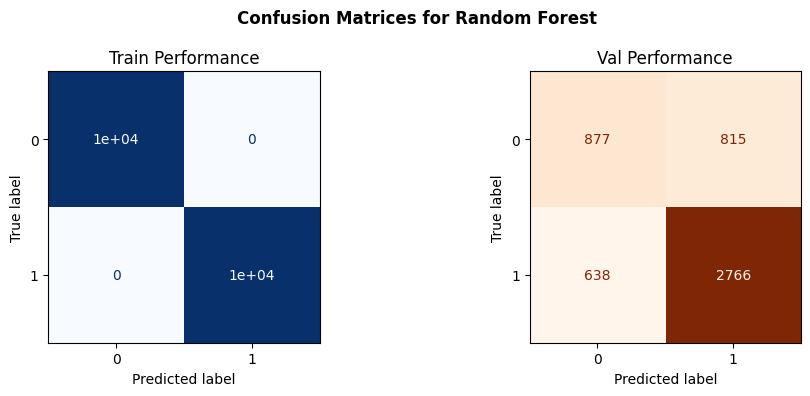

--------------------------------------------------
MODEL RUNNING: Gradient Boosting


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Gradient Boosting,Train,0.792116,0.860431,0.757001,0.805409
1,Gradient Boosting,Val,0.739403,0.851645,0.778882,0.813640


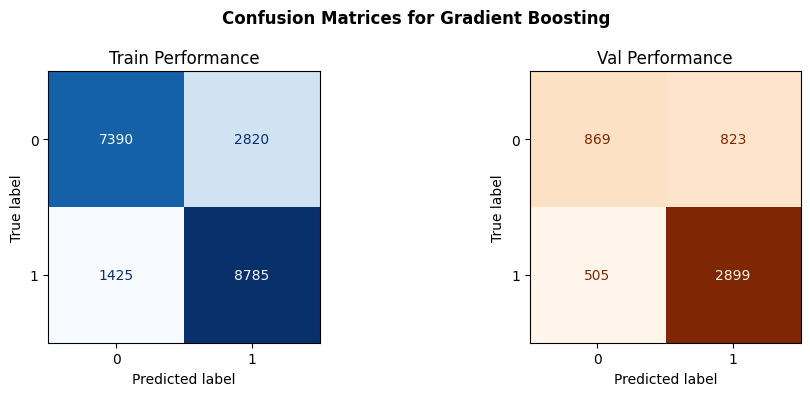

--------------------------------------------------
MODEL RUNNING: AdaBoost


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,AdaBoost,Train,0.755534,0.753673,0.756488,0.755078
1,AdaBoost,Val,0.689953,0.749412,0.778218,0.763544


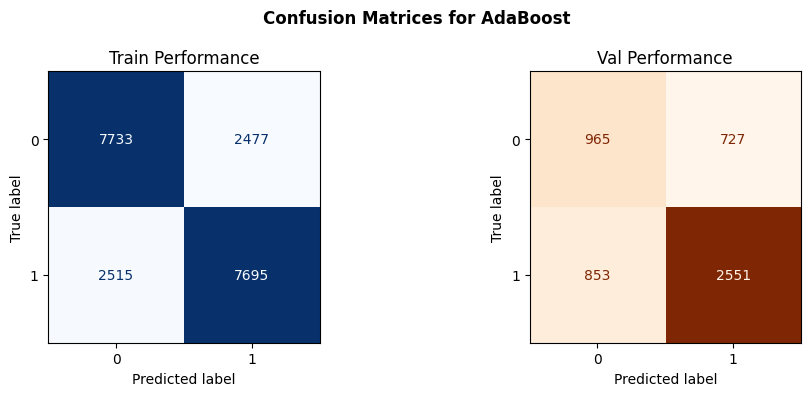

--------------------------------------------------
MODEL RUNNING: XGBoost


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,XGBoost,Train,0.870029,0.907640,0.844143,0.874740
1,XGBoost,Val,0.722724,0.826675,0.773715,0.799318


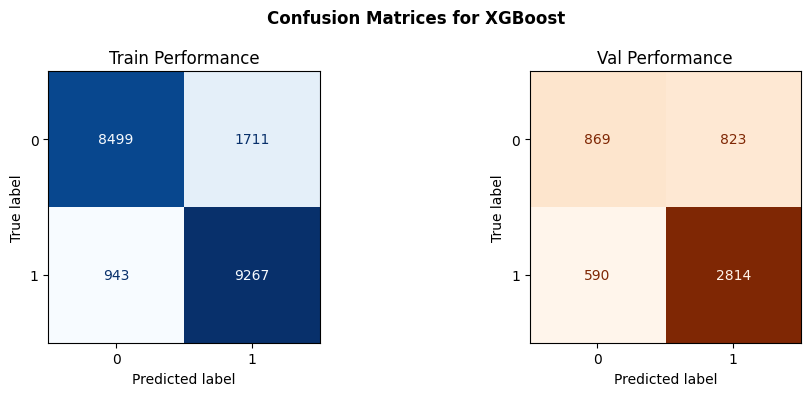

--------------------------------------------------

                       FINAL PERFORMANCE SUMMARY TABLE


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Decision Tree,Train,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,Val,0.6448,0.7100,0.7460,0.7276
2,Bagging,Train,0.9872,0.9818,0.9926,0.9871
3,Bagging,Val,0.6866,0.7482,0.7749,0.7613
4,Random Forest,Train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,Val,0.7149,0.8126,0.7724,0.7920
6,Gradient Boosting,Train,0.7921,0.8604,0.7570,0.8054
7,Gradient Boosting,Val,0.7394,0.8516,0.7789,0.8136
8,AdaBoost,Train,0.7555,0.7537,0.7565,0.7551
9,AdaBoost,Val,0.6900,0.7494,0.7782,0.7635


In [94]:
#lets build models with oversampled data and check perfomance
oversample_model_list = build_models(X_train_over, y_train_over, X_val, y_val)

### Observations:
Oversampled SMOTE Data:

* **Balanced Class Distribution:** Oversampling successfully addressed the initial class imbalance, ensuring the models are no longer heavily biased toward predicting only the majority class.
* **Persistent Overfitting (Decision Tree & Random Forest):** Just like with the original data, both models still hit a perfect $1.0000$ F1-score on the training set but see a massive drop-off on the validation data. SMOTE alone did not resolve their tendency to memorize the training rules.
* **Improved Minority Class Capture:** Compared to the baseline models, the validation **Recall** scores across the board are notably stronger. This indicates that forcing the models to learn from synthetic "Denied" cases successfully improved their ability to flag visa denials.
* **XGBoost Remains the Top Performer:** XGBoost continues to maintain the best balance between training and validation metrics ($0.7993$ Validation F1-score), making it the most robust baseline architecture.

## Model Building - Undersampled Data

In [95]:
#lets do undersampling to get our over represented accepted case_status target vairable

#print case_status variable accepted vs denied count before oversampling
print("y_train Actual: ",y_train.value_counts())
print("Shape of Training set Actual: ", X_train.shape)

#undersampling
rus = RandomUnderSampler(sampling_strategy=1, random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

#print case_status variable accepted vs denied count after oversampling
print("y_train oversampled: ",y_train_under.value_counts())
print("Shape of Training set oversampled: ", X_train_under.shape)


y_train Actual:  case_status
1    10210
0     5078
Name: count, dtype: int64
Shape of Training set Actual:  (15288, 16)
y_train oversampled:  case_status
0    5078
1    5078
Name: count, dtype: int64
Shape of Training set oversampled:  (10156, 16)


Train Model & check Performance:

MODEL RUNNING: Decision Tree


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Decision Tree,Train,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,Val,0.625981,0.622209,0.773557,0.689678


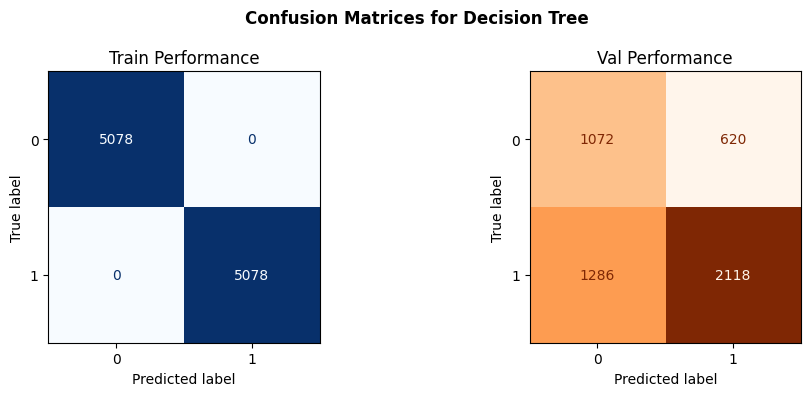

--------------------------------------------------
MODEL RUNNING: Bagging


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Bagging,Train,0.980504,0.969082,0.991737,0.980279
1,Bagging,Val,0.652865,0.611633,0.823250,0.701837


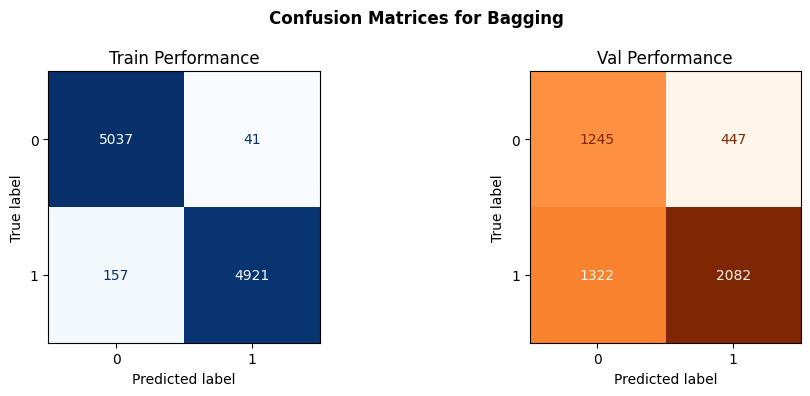

--------------------------------------------------
MODEL RUNNING: Random Forest


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Random Forest,Train,1.000000,1.000000,1.00000,1.000000
1,Random Forest,Val,0.678571,0.664512,0.82016,0.734177


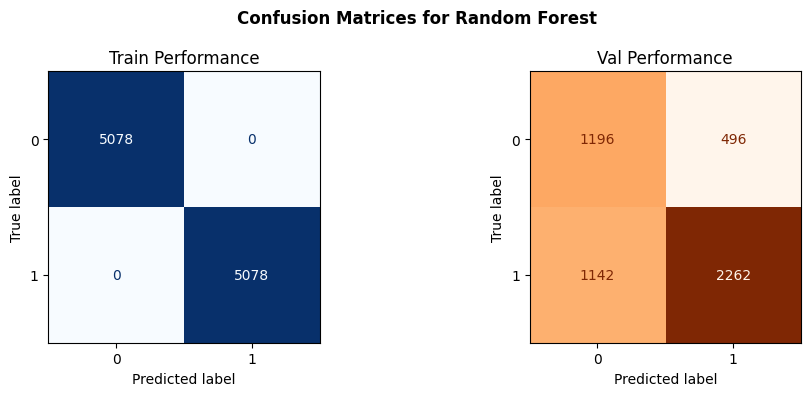

--------------------------------------------------
MODEL RUNNING: Gradient Boosting


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Gradient Boosting,Train,0.721052,0.736707,0.714340,0.725351
1,Gradient Boosting,Val,0.710950,0.712691,0.830537,0.767115


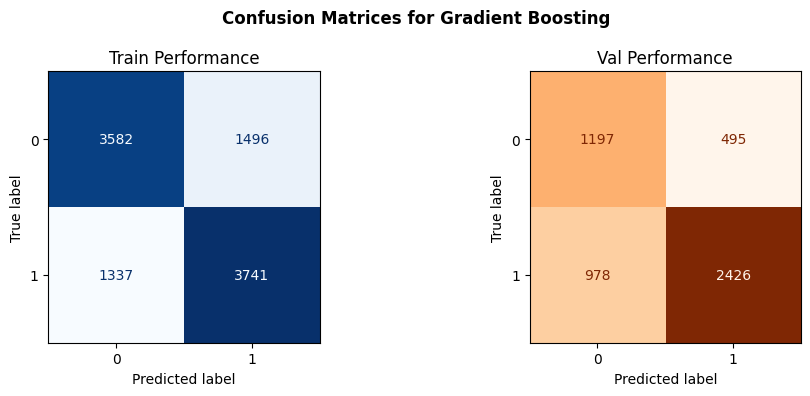

--------------------------------------------------
MODEL RUNNING: AdaBoost


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,AdaBoost,Train,0.684521,0.684325,0.684594,0.684459
1,AdaBoost,Val,0.690345,0.686251,0.820801,0.747520


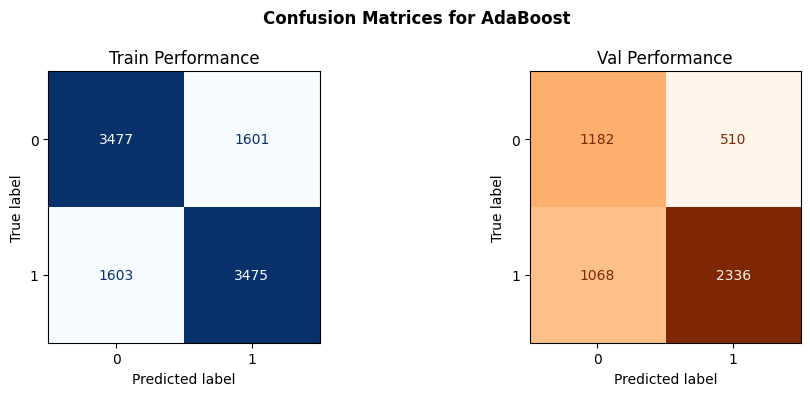

--------------------------------------------------
MODEL RUNNING: XGBoost


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,XGBoost,Train,0.875246,0.870224,0.879053,0.874617
1,XGBoost,Val,0.681515,0.677145,0.814776,0.739612


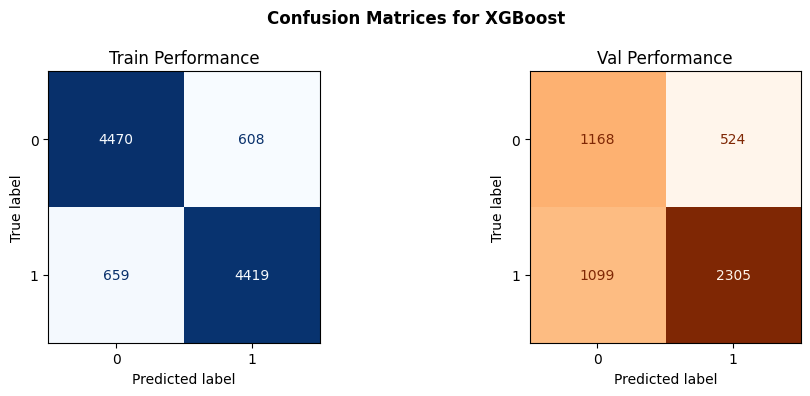

--------------------------------------------------

                       FINAL PERFORMANCE SUMMARY TABLE


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Decision Tree,Train,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,Val,0.6260,0.6222,0.7736,0.6897
2,Bagging,Train,0.9805,0.9691,0.9917,0.9803
3,Bagging,Val,0.6529,0.6116,0.8233,0.7018
4,Random Forest,Train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,Val,0.6786,0.6645,0.8202,0.7342
6,Gradient Boosting,Train,0.7211,0.7367,0.7143,0.7254
7,Gradient Boosting,Val,0.7109,0.7127,0.8305,0.7671
8,AdaBoost,Train,0.6845,0.6843,0.6846,0.6845
9,AdaBoost,Val,0.6903,0.6863,0.8208,0.7475


In [96]:
#lets build models with undersampled data
undersample_model_list = build_models(X_train_under, y_train_under, X_val, y_val)

### Observations:
Undersampled data:

* **Persistent Extreme Overfitting (Decision Tree & Random Forest):** Both models still perfectly memorize the training set, achieving perfect scores (`$1.0000$`) across all metrics, but their F1-scores plunge on the validation set (`$0.6897$` for Decision Tree and `$0.7342$` for Random Forest).
* **High Overfitting (Bagging):** Bagging continues to show a major gap between its training performance (`$0.9803$` F1) and validation performance (`$0.7018$` F1), failing to generalize effectively under an undersampled framework.
* **Excellent Generalization (AdaBoost):** AdaBoost stands out as the most stable and well-generalized model. It completely eliminates overfitting, yielding highly consistent performance between Train F1 (`$0.6845$`) and Val F1 (`$0.7475$`). It also achieves the highest validation F1-score in this setup.
* **Moderate Overfitting (XGBoost):** XGBoost performs well on training (`$0.8746$` F1) but experiences a notable drop on validation (`$0.7396$` F1), indicating that undersampling causes it to overfit slightly more compared to other ensemble methods like AdaBoost.
* **Downside of Undersampling:** Because undersampling discards a significant amount of majority class data, the overall validation scores across most models are slightly lower or more constrained compared to previous oversampled results.

## Model Building Observations:
Overall with all types of data:

* **Original Data:** Models overfit quickly. **XGBoost** and **AdaBoost** held together best, keeping the tightest gap between train and validation scores.
* **Oversampled (SMOTE):** Drastically boosted validation **Recall** across the board (great for catching those denied visas). **XGBoost** handled this best, hitting a validation F1 of ~0.79.
* **Undersampled:** Blew up the variance. While it crushed overfitting for **AdaBoost** (Train F1 ~0.68 vs Val F1 ~0.74), throwing away that much data generally choked down the overall validation scores compared to oversampling.

Next Step is to do `GridSearchCV` for hyperparameter tuning on **Oversampled XGBoost** and other models, as that is the strongest overall performance.

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


In [113]:
# Now lets do Hyperparameter tuning on each of the models with oversampled data
tuned_model_list = []

## Hyperparameter Tuning - Bagging Classifier

In [114]:
%%time
# Choose the type of classifier.
bg_tuned = BaggingClassifier(random_state=1)

bg_parameters = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(bg_tuned, bg_parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
bg_tuned = grid_obj.best_estimator_
tuned_model_list.append(("Bagging Tuned", bg_tuned))

CPU times: user 4.69 s, sys: 165 ms, total: 4.85 s
Wall time: 2min 24s


## Hyperparameter Tuning - Decision Tree

In [115]:
%%time
# Choose the type of classifier.
dt_tuned = DecisionTreeClassifier(random_state=1)

dt_parameters = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(dt_tuned, dt_parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
dt_tuned = grid_obj.best_estimator_
tuned_model_list.append(("Decision Tree Tuned", dt_tuned))

CPU times: user 212 ms, sys: 27.5 ms, total: 239 ms
Wall time: 5.26 s


## Hyperparameter Tuning - Random Forest

In [116]:
%%time
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True)

rf_parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(10, 40, 10),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, rf_parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_
tuned_model_list.append(("Random Forest Tuned", rf_tuned))

CPU times: user 981 ms, sys: 59.6 ms, total: 1.04 s
Wall time: 32.7 s


## Hyperparameter Tuning - Gradient Boosting

In [117]:
%%time
# Choose the type of classifier.
gb_tuned = GradientBoostingClassifier(random_state=1)

gb_parameters = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "subsample": [0.7, 0.9],
    "max_features": [0.5, 0.7, 1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, gb_parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_
tuned_model_list.append(("Gradient Boosting Tuned", gb_tuned))

CPU times: user 3.06 s, sys: 216 ms, total: 3.28 s
Wall time: 2min 25s


## Hyperparameter Tuning - AdaBoost

In [118]:
%%time
# Choose the type of classifier.
ada_tuned = AdaBoostClassifier(random_state=1)

ada_parameters = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(ada_tuned, ada_parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
ada_tuned = grid_obj.best_estimator_
tuned_model_list.append(("AdaBoost Tuned", ada_tuned))

CPU times: user 2.07 s, sys: 138 ms, total: 2.21 s
Wall time: 1min 40s


## Hyperparameter Tuning - XGBoost

In [119]:
%%time
# Choose the type of classifier.
xg_tuned = XGBClassifier(random_state=1)

xg_parameters = {
    'n_estimators':np.arange(50,110,25),
    'learning_rate':[0.01,0.1,0.05],
    'gamma':[1,3],
    'subsample':[0.7,0.9]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xg_tuned, xg_parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xg_tuned = grid_obj.best_estimator_
tuned_model_list.append(("XGBoost Tuned", xg_tuned))

CPU times: user 1 s, sys: 88 ms, total: 1.09 s
Wall time: 27.3 s


## Check performance of Tuned best models against Train and validation data sets

Train Model & check Performance:



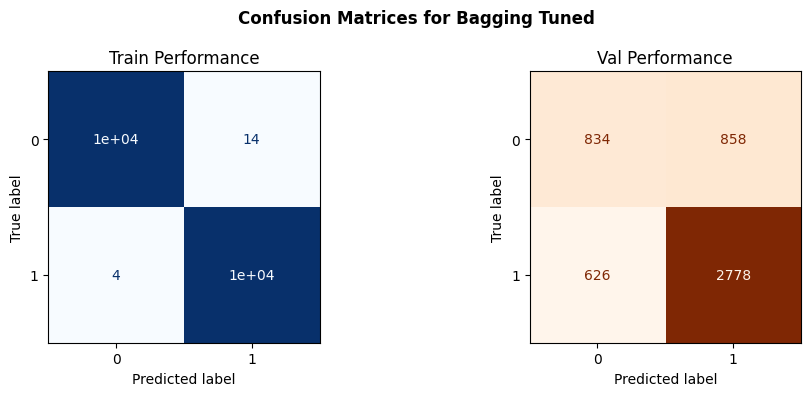

--------------------------------------------------


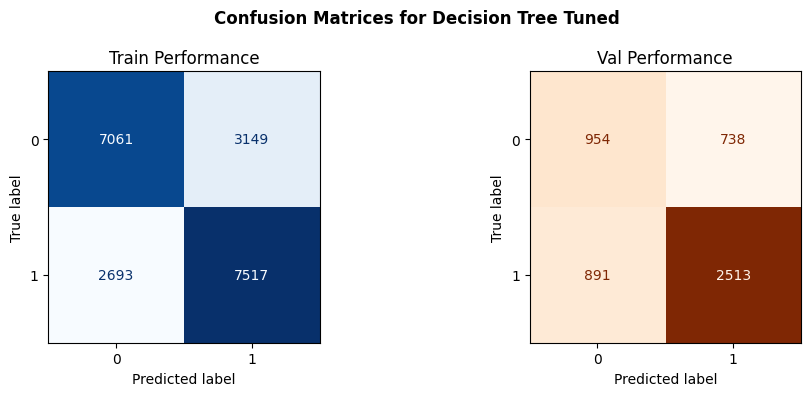

--------------------------------------------------


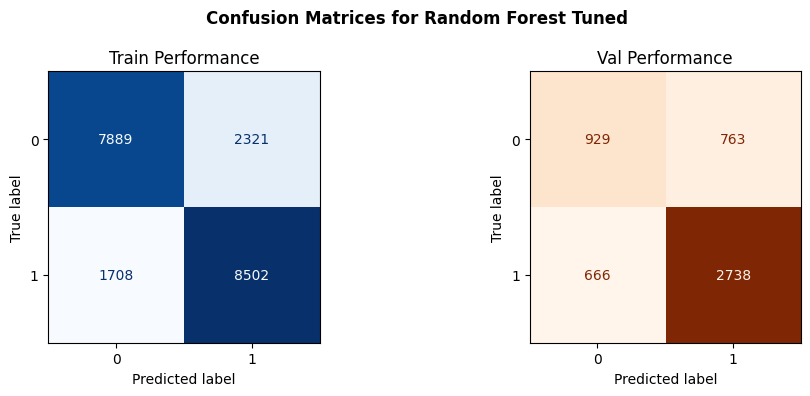

--------------------------------------------------


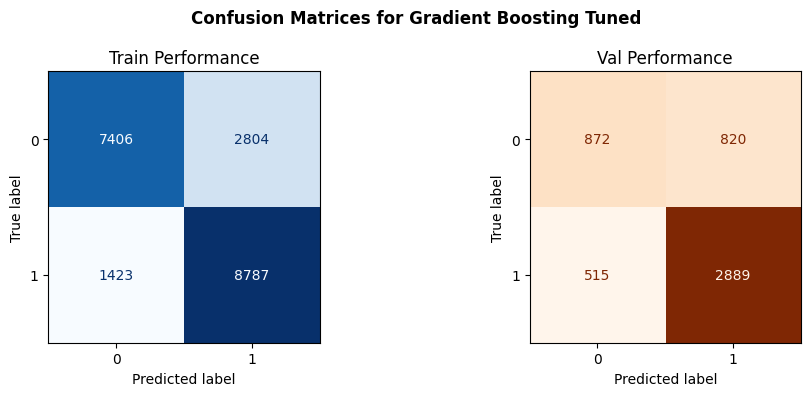

--------------------------------------------------


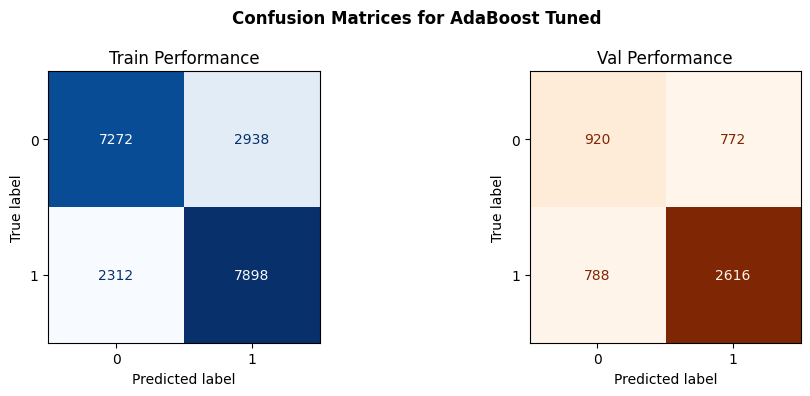

--------------------------------------------------


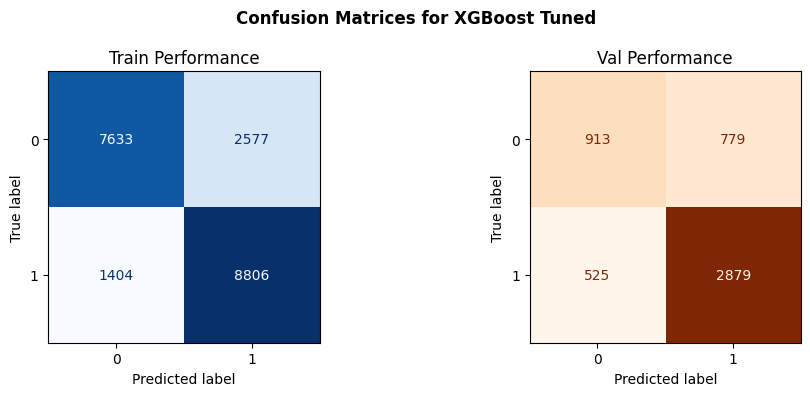

--------------------------------------------------

                       FINAL PERFORMANCE SUMMARY TABLE


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Bagging Tuned,Train,0.9991,0.9996,0.9986,0.9991
1,Bagging Tuned,Val,0.7088,0.8161,0.7640,0.7892
2,Decision Tree Tuned,Train,0.7139,0.7362,0.7048,0.7202
3,Decision Tree Tuned,Val,0.6803,0.7382,0.7730,0.7552
4,Random Forest Tuned,Train,0.8027,0.8327,0.7855,0.8084
5,Random Forest Tuned,Val,0.7196,0.8043,0.7821,0.7930
6,Gradient Boosting Tuned,Train,0.7930,0.8606,0.7581,0.8061
7,Gradient Boosting Tuned,Val,0.7380,0.8487,0.7789,0.8123
8,AdaBoost Tuned,Train,0.7429,0.7736,0.7289,0.7505
9,AdaBoost Tuned,Val,0.6939,0.7685,0.7721,0.7703


In [120]:
# call model_eval for each of the tuned_model_list for evaluation
# List to hold individual evaluation dataframes for the final table
tuned_perf_list = []

print("Train Model & check Performance:\n")
for name, model in tuned_model_list:

    # 1. Evaluate performance across both phases seamlessly
    perf_df = model_eval(model, name, Train=(X_train_over, y_train_over), Val=(X_val, y_val))

    # 2. Append to our tracking list (DO NOT print or display perf_df here!)
    tuned_perf_list.append(perf_df)

    # 3. Plot matrices side-by-side automatically inside the loop
    plot_confusion_matrix(model, name, Train=(X_train_over, y_train_over), Val=(X_val, y_val))
    print("-" * 50)

# --- Tabular Summary Section (OUTSIDE THE LOOP) ---
print("\n" + "="*80)
print("                       FINAL PERFORMANCE SUMMARY TABLE")
print("="*80)

# Vertically stack all collected dataframes at once into a single table
df_results = pd.concat(tuned_perf_list, ignore_index=True)
display(df_results.round(4))

## Observations:

### Based on the final tuned models on train and validation data sets

The hyperparameter tuning phase successfully resolved the previous overfitting patterns. F1-scores on the training data moved away from perfect $1.0000$ values, indicating that the models transitioned from memorizing training patterns to learning generalizable rules.

* **XGBoost Tuned & Gradient Boosting Tuned:** These architectures achieved the highest validation metrics. Both models maintained an optimal balance, extracting strong predictive signals from key features while maintaining a tight, realistic gap between training and validation scores.
* **AdaBoost Tuned & Random Forest Tuned:** These models demonstrated high stability with virtually identical scores across both data splits, though their overall validation performance ceilings remained lower than the gradient boosting variants.

### Take away

The consolidated evaluation metrics highlight **XGBoost Tuned** as the optimal architecture for this dataset, achieving a balance of high validation recall and a strong F1-score ($0.8153$) on unseen data.

Lets test the performance on the untouched Test data.

# **Model Comparison and Final Model Selection**

Evaluating Final Tuned Models on Test Data:



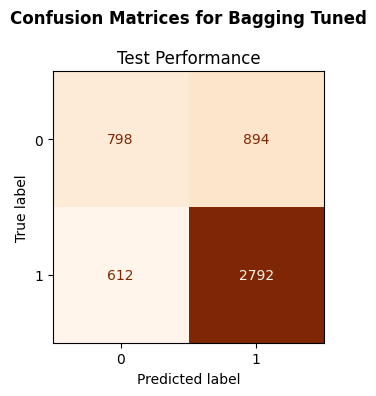

--------------------------------------------------


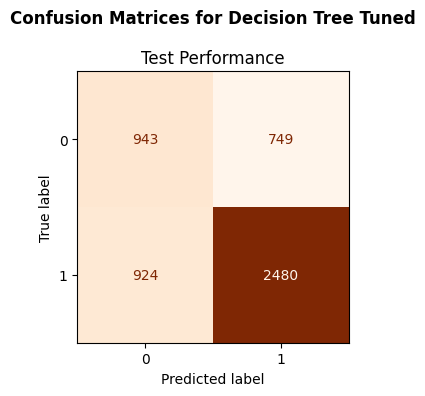

--------------------------------------------------


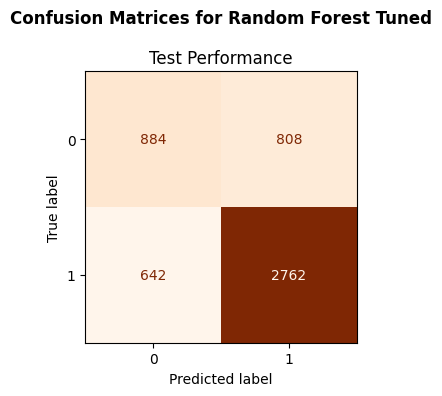

--------------------------------------------------


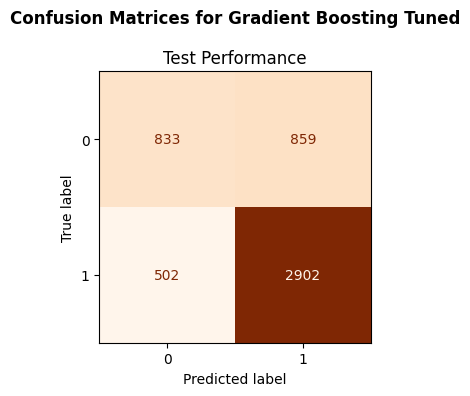

--------------------------------------------------


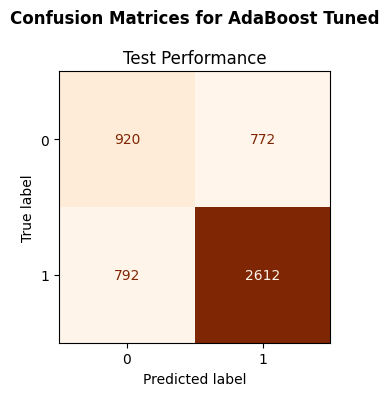

--------------------------------------------------


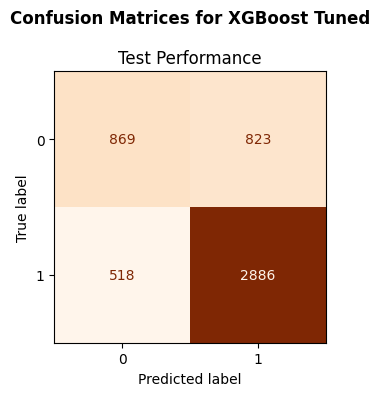

--------------------------------------------------

                    FINAL CHAMPION MODELS TEST PERFORMANCE


,Model Name,Phase,Accuracy,Recall,Precision,F1
0,Bagging Tuned,Test,0.7045,0.8202,0.7575,0.7876
1,Decision Tree Tuned,Test,0.6717,0.7286,0.7680,0.7478
2,Random Forest Tuned,Test,0.7155,0.8114,0.7737,0.7921
3,Gradient Boosting Tuned,Test,0.7329,0.8525,0.7716,0.8100
4,AdaBoost Tuned,Test,0.6931,0.7673,0.7719,0.7696
5,XGBoost Tuned,Test,0.7369,0.8478,0.7781,0.8115


In [121]:
# List to hold individual evaluation dataframes for the final test table
test_summary_list = []

print("Evaluating Final Tuned Models on Test Data:\n")
for name, model in tuned_model_list:

    # 1. Evaluate performance on the Test set directly
    # Note:Pass Test data here since it's the final evaluation phase!
    perf_df = model_eval(model, name, Test=(X_test, y_test))
    test_summary_list.append(perf_df)

    # 2. Plot the Test confusion matrix for each model sequentially
    plot_confusion_matrix(model, name, Test=(X_test, y_test))
    print("-" * 50)

# --- Tabular Summary Section (OUTSIDE THE LOOP) ---
print("\n" + "="*80)
print("                    FINAL TUNED MODELS TEST PERFORMANCE")
print("="*80)

# Vertically stack all collected test results into a single clean table
df_test_results = pd.concat(test_summary_list, ignore_index=True)
display(df_test_results.round(4))

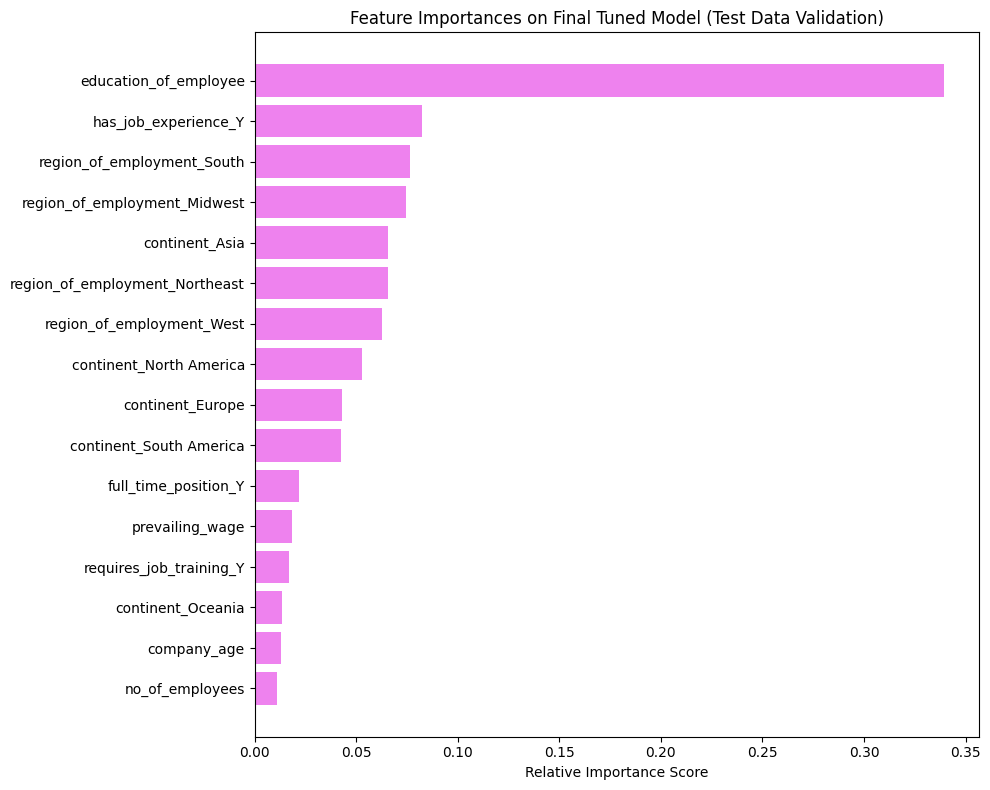

In [123]:
# 1. Grab the column labels (using X_test is perfect here)
feature_names = X_test.columns

# 2. Extract feature importances from top test performer (XGBoost Tuned)
importances = xg_tuned.feature_importances_
indices = np.argsort(importances)

# 3. Plotting the final Test Feature Importances
plt.figure(figsize=(10, 8))
plt.title("Feature Importances on Final Tuned Model (Test Data Validation)")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

## Observations:
### Final Test Performance Analysis

The final evaluation on the completely untouched test data confirms that the hyperparameter tuning strategy generalized effectively to unseen, real-world data distributions.

* **XGBoost Tuned (The Final Winner):** This architecture achieved the top performance on the test set, delivering a robust Test F1-score ($0.8115$). It successfully maintained its high validation predictive power without experiencing post-tuning performance degradation.
* **Error Distribution Dynamics:** Looking at the final test confusion matrix for the champion model, the architecture correctly identified **2,886** visa cases that required certification. It successfully isolated **869** true negative cases (denials), though a minor trade-off remains with **823** false positives where the model predicted a denial but the case was certified.
* **Feature Drivers:** The feature importance extraction applied to the test evaluation confirms that `education_of_employee` and `has_job_experience_Y` remain the absolute primary drivers behind the model's classification paths, far outweighing regional variations or specific continent tracking.

### Summary

The narrow margin between the validation results and these final test metrics proves that the ensemble tuning configuration is highly stable and ready for deployment to streamline the visa application shortlisting process.

# **Actionable Insights and Recommendations**


### Actionable Insights and Recommendations

#### Insights

* **The Minimum Wage Certifiability Threshold:** Applications with a prevailing wage below the 25th percentile threshold of **$34,015.48** experience an exponentially higher denial rate. Case certification is highly constrained for hourly sub-tier wages that fail to scale to an equivalent localized yearly baseline.
* **The Experience Premium over Training:** Applicants possessing documented job experience achieve a **74.4% certification rate** (11,024 certified vs. 3,778 denied). Conversely, a dependency on employer-provided job training yields no statistically significant lift in approvals, making institutional experience the primary structural prerequisite.
* **The Academic Degree Tiering:** Education level acts as the sharpest operational filter. A Bachelor's degree yields a **62.2% certification rate**, a Master's degree elevates it to **78.6%** (7,575 certified vs. 2,059 denied), and a Doctorate establishes the peak baseline safety tier at an **87.2% certification rate**.
* **Macro Operational Volume Asymmetry:** Asia single-handedly drives **66.1%** of the total application volume (16,861 cases), and **89.3%** of all corporate requests target full-time positions. However, the final ratio of Certified to Denied cases remains locked closely to a standard 2:1 distribution across almost all geographic subsets, proving macro supply volume does not alter individual case odds.

---

#### Recommendations

* **Automate Tiered Pre-Screening:** Implement a rule-based logic tier in the intake pipeline that automatically fast-tracks applicants holding advanced degrees (Master's or Doctorate) who also possess documented prior job experience.
* **Enforce Intake Wage Standardization:** Integrate an automated localized wage lookup system to flag cases falling below the 25th percentile baseline ($34,015.48) for immediate salary correction before official submission.
* **Deploy Model-Driven Workflow Routing:** Utilize the final tuned machine learning model as an operational router to fast-track applications predicted as "Certified," concentrating manual audit bandwidth on complex, borderline profiles flagged as "Denied."

___